# Day-ahead load forecasting — portfolio of 410 heat-pump households

**Task.** At **24:00 of day D-1** forecast the **aggregated load of all households for every 15-min interval of day D**
(96 values). **Only information available at 24:00 of D-1 is used — no perfect foresight of any kind.**

**Models**
| # | Model | Idea |
|---|---|---|
| 1 | Baseline | load of the same quarter-hour **7 days earlier** |
| 2 | Linear regression | ridge-regularised linear model on calendar, load-lag and past-weather features |
| 3 | Random forest | non-linear tree ensemble on the same features |
| 4 | LSTM | sequence-to-sequence network: encoder reads the last 7 days, decoder emits the 96 quarter-hours of day D |

**Notebook structure**
1. Setup & configuration
2. Data preparation (portfolio aggregation, weather, features, 80/20 split)
3. Feature importance analysis
4. Hyperparameter optimisation & training (time-series cross-validation inside the training period only)
5. Validation on the 20% hold-out test period
6. Conclusions

**Design decisions** (all configurable in section 1)
* **Target = aggregated load of all households.** The number of households in the data grows from ~10 (2019) to
  ~400 (2023). The models therefore learn the **load per household** (kWh / 15 min) and the forecast is multiplied by the
  number of households in the portfolio **on D-1** (the latest known portfolio size). Readings missing because of
  meter gaps are imputed with the mean of the other households. The baseline is applied literally to the aggregated
  load: `forecast(D, t) = total(D-7, t)`.
* **Modelling period** starts when ≥ `MIN_HOUSEHOLDS` (50) households report — the mean over a handful of houses
  is not representative (≈ Nov 2020 → Feb 2024).
* **Time axis:** fixed UTC+1 (CET without daylight saving), so every day has exactly 96 quarter-hours. A
  daylight-saving flag lets the models learn the 1-hour shift of human behaviour in summer.
* **No perfect foresight.** A forecast for day D may use only what is known at 24:00 of D-1:
  * load measurements up to the quarter-hour 23:45–24:00 of D-1,
  * **weather measured up to 23:00 of D-1** — the dataset contains no weather forecasts, so the weather of day D is
    **not** used in any form (there is no measured "tomorrow's temperature" among the features),
  * the calendar of day D (weekday, public holiday, daylight saving) — known in advance,
  * the portfolio size of D-1.

  The pre-processing is causal as well: hourly weather is upsampled by *holding* each hourly value (no interpolation
  towards later measurements), gaps in the load history are filled only with earlier values, and all scalers,
  feature analyses and hyperparameter searches use the training period only.
* **Split:** first 80% of days = training, last 20% = test. Hyperparameters are tuned with expanding-window
  cross-validation **inside** the training period; the test period is used exactly once, for the final validation.

## 1. Setup & configuration

In [40]:
import copy
import json
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.easter import easter
from IPython.display import display

import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 40)

# ---------------- configuration ----------------
DATA = Path("data")
CACHE = DATA / "_cache"
RESULTS = Path("results")
CACHE.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

TZ = "Etc/GMT-1"         # fixed UTC+1 (no DST) -> every day has exactly 96 quarter-hours
STEPS = 96               # quarter-hours per day
MIN_HOUSEHOLDS = 50      # modelling period starts once at least this many households report
MAX_KWH_15MIN = 10.0     # single readings above 10 kWh / 15 min (= 40 kW) are meter errors -> dropped
TEST_SHARE = 0.2         # last 20% of the days = test set
N_FOLDS = 3              # expanding-window CV folds inside the training period
RUN_HPO = True           # False -> reuse the best parameters stored in data/_cache/best_params.json
N_TRIALS_RF = 3
N_TRIALS_LSTM = 3
LSTM_MAX_EPOCHS = 6
LSTM_PATIENCE = 10
LSTM_ENSEMBLE = 1        # final LSTM = average of this many seeds (reduces run-to-run variance)
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))

# ---------------- plotting ----------------
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
C_BLUE, C_ORANGE, C_AQUA = PALETTE[:3]
C_GREY, C_INK = "#9a9994", "#0b0b0b"
MODEL_COLORS = {"Baseline (t-7d)": C_GREY, "Linear regression": C_BLUE, "Random forest": C_ORANGE, "LSTM": C_AQUA}
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (12, 4.5),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "grid.color": "#e6e5e0", "lines.linewidth": 2, "legend.frameon": False,
})
print(f"torch {torch.__version__} | optuna {optuna.__version__} | threads {torch.get_num_threads()}")

torch 2.14.1+cpu | optuna 5.0.0 | threads 8


## 2. Data preparation
### 2.1 Aggregate all households to one 15-min portfolio series
For every quarter-hour we store the **sum** over all reporting households and the **number** of reporting households.
Implausible single readings (> 10 kWh per 15 min, found in the EDA) are discarded. Result is cached.

In [41]:
AGG_FILE = CACHE / "portfolio_15min.pkl"
if AGG_FILE.exists():
    agg15 = pd.read_pickle(AGG_FILE)
    print("Loaded", AGG_FILE)
else:
    t0 = time.time()
    grid = pd.date_range("2019-05-20", "2024-02-28", freq="15min", tz="UTC", inclusive="left")
    s_sum = np.zeros(len(grid))
    s_cnt = np.zeros(len(grid), dtype=np.int32)
    n_dropped = 0
    for f in sorted((DATA / "15min").glob("*.csv")):
        d = pd.read_csv(f, sep=";", usecols=["Timestamp", "kWh_received_Total"])
        ts = pd.to_datetime(d.Timestamp, utc=True, format="%Y-%m-%d %H:%M:%S%z")
        pos = ((ts - grid[0]) // pd.Timedelta("15min")).to_numpy()
        val = d.kWh_received_Total.to_numpy(dtype=float)
        ok = ~np.isnan(val) & (val <= MAX_KWH_15MIN)
        n_dropped += int((val > MAX_KWH_15MIN).sum())
        np.add.at(s_sum, pos[ok], val[ok])
        np.add.at(s_cnt, pos[ok], 1)
    agg15 = pd.DataFrame({"sum": s_sum, "n": s_cnt}, index=grid)
    agg15.to_pickle(AGG_FILE)
    print(f"Aggregated 410 files in {time.time() - t0:.0f}s, dropped {n_dropped} implausible readings -> {AGG_FILE}")

agg15 = agg15.tz_convert(TZ)
agg15.describe().T

Loaded data\_cache\portfolio_15min.pkl


,count,mean,std,min,25%,50%,75%,max
sum,"167,520.0000",50.1588,54.0592,0.0000,7.4280,33.8430,69.1270,318.7700
n,"167,520.0000",165.1329,141.7540,0.0000,31.0000,118.0000,323.0000,390.0000


### 2.2 Contracted households per day and the target
A household counts as *contracted* on every day between its first and last timestamp
(`smart_meter_data_15min_overview.csv`), split by its weather station (needed for weighting the weather in 2.3).

In [42]:
META = DATA / "smart_meter_meta_data"
households = pd.read_csv(META / "households.csv", sep=";")
overview = pd.read_csv(META / "smart_meter_data_15min_overview.csv", sep=";")
ov = overview.merge(households[["Household_ID", "Weather_ID"]], on="Household_ID")
ov["first_day"] = pd.to_datetime(ov.SMD_15min_TimeAvailable_EarliestTimestamp, utc=True).dt.tz_convert(TZ).dt.floor("D")
ov["last_day"] = pd.to_datetime(ov.SMD_15min_TimeAvailable_LatestTimestamp, utc=True).dt.tz_convert(TZ).dt.floor("D")

all_days = pd.date_range(ov.first_day.min(), ov.last_day.max(), freq="D")
n_contract_st = pd.DataFrame(0, index=all_days, columns=sorted(ov.Weather_ID.unique()))
for r in ov.itertuples():
    n_contract_st.loc[r.first_day:r.last_day, r.Weather_ID] += 1
n_contract = n_contract_st.sum(axis=1)

# modelling period: from the first day on which >= MIN_HOUSEHOLDS report in every quarter-hour
daily_min_n = agg15.n.resample("D").min()
start_day = daily_min_n[daily_min_n >= MIN_HOUSEHOLDS].index[0]
last_day = (agg15.index[-1] + pd.Timedelta("15min")).floor("D") - pd.Timedelta(days=1)
df = agg15.loc[start_day: last_day + pd.Timedelta(hours=23, minutes=45)].copy()
df["mean_kwh"] = df["sum"] / df["n"].where(df["n"] >= MIN_HOUSEHOLDS)        # load per reporting household
df["mean_kwh_hist"] = df.mean_kwh.ffill(limit=8)   # causal copy for the features: last observed value, max. 2 h

# target only: interpolate short gaps (<= 2 h) between the neighbouring measurements, keep longer gaps missing
na = df.mean_kwh.isna()
run_len = na.groupby((na != na.shift()).cumsum()).transform("sum")
fill = na & (run_len <= 8)
df.loc[fill, "mean_kwh"] = df.mean_kwh.interpolate(limit_area="inside")[fill]
print(f"Interpolated {fill.sum()} quarter-hours in short gaps; {df.mean_kwh.isna().sum()} quarter-hours remain missing")
df["n_contract"] = n_contract.reindex(df.index.floor("D")).to_numpy()
df["total_kwh"] = df.mean_kwh * df.n_contract                                 # aggregated portfolio load
print(f"Modelling period: {start_day:%Y-%m-%d} -> {last_day:%Y-%m-%d}  ({len(df) // STEPS} days, {len(df):,d} quarter-hours)")

Interpolated 0 quarter-hours in short gaps; 288 quarter-hours remain missing
Modelling period: 2020-11-04 -> 2024-02-27  (1211 days, 116,256 quarter-hours)


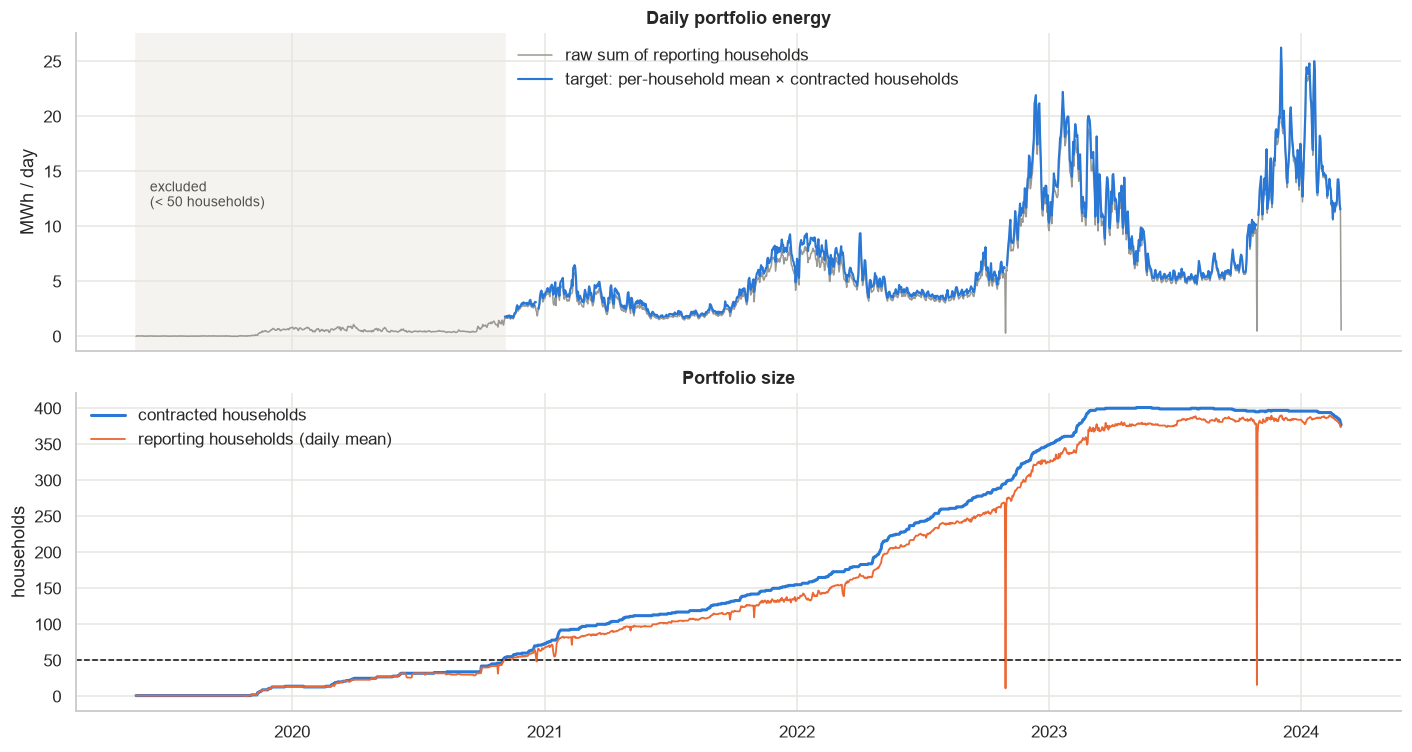

In [43]:
full = agg15.assign(day=agg15.index.floor("D"))
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
daily_tot = (full["sum"].resample("D").sum() / 1000)
axes[0].plot(daily_tot.index, daily_tot, color=C_GREY, lw=1, label="raw sum of reporting households")
dt = df.total_kwh.resample("D").sum(min_count=STEPS) / 1000
axes[0].plot(dt.index, dt, color=C_BLUE, lw=1.4, label="target: per-household mean × contracted households")
axes[0].axvspan(daily_tot.index[0], start_day, color="#f4f3ef", zorder=0)
axes[0].text(daily_tot.index[20], dt.max() * .45, f"excluded\n(< {MIN_HOUSEHOLDS} households)", fontsize=9, color="#52514e")
axes[0].set_ylabel("MWh / day"); axes[0].set_title("Daily portfolio energy"); axes[0].legend(loc="upper center")
axes[1].plot(n_contract.index, n_contract, color=C_BLUE, label="contracted households")
axes[1].plot(daily_min_n.index, agg15.n.resample("D").mean(), color=C_ORANGE, lw=1.2, label="reporting households (daily mean)")
axes[1].axhline(MIN_HOUSEHOLDS, color=C_INK, ls="--", lw=1)
axes[1].set_ylabel("households"); axes[1].set_title("Portfolio size"); axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

### 2.3 Weather: one portfolio-weighted series at 15-min resolution
Hourly station data are upsampled to 15 min by **holding each hourly value for its four quarter-hours** (no
interpolation, so no quarter-hour ever sees a later measurement) and averaged over the 8 stations,
**weighted by the number of contracted households at each station** on that day. Stations missing a variable are
left out of that variable's average.

These series are only used **lagged** (D-1 and earlier) as features. The weather of the target day itself is
used solely to *describe* test days in section 5 (e.g. "coldest day"), never as model input.

In [44]:
weather = pd.concat([pd.read_csv(f, sep=";") for f in sorted((DATA / "weather_data_hourly").glob("*.csv"))],
                    ignore_index=True)
weather["Timestamp"] = pd.to_datetime(weather.Timestamp, utc=True).dt.tz_convert(TZ)
WX_MAP = {"Temperature_avg_hourly": "temp", "Sunshine_duration_hourly": "sunshine",
          "Humidity_avg_hourly": "humidity", "WindSpeed_hourly": "wind"}

def portfolio_weighted(wide):
    W = n_contract_st.reindex(wide.index.floor("D")).fillna(0).to_numpy(float)
    V = wide.reindex(columns=n_contract_st.columns).to_numpy(float)
    W = np.where(np.isnan(V), 0.0, W)
    with np.errstate(invalid="ignore", divide="ignore"):
        return pd.Series(np.nansum(V * W, axis=1) / W.sum(axis=1), index=wide.index)

for raw, name in WX_MAP.items():
    wide = weather.pivot_table(index="Timestamp", columns="Weather_ID", values=raw).asfreq("h")
    up = wide.resample("15min").asfreq()
    up = up.ffill(limit=3)                       # zero-order hold: causal
    df[name] = portfolio_weighted(up).reindex(df.index).to_numpy()

display(df[list(WX_MAP.values())].describe().T)
print("Missing weather values in modelling period:", df[list(WX_MAP.values())].isna().sum().to_dict())

,count,mean,std,min,25%,50%,75%,max
temp,"116,256.0000",10.0484,8.0483,-11.9720,3.5781,9.3490,15.8346,35.4020
sunshine,"116,256.0000",0.1971,0.3568,0.0000,0.0000,0.0000,0.1733,1.0000
humidity,"116,256.0000",77.5855,17.1885,19.1140,67.2078,82.5057,91.4812,99.6068
wind,"116,256.0000",2.0589,1.5007,0.1714,0.9610,1.6095,2.7429,11.4475


Missing weather values in modelling period: {'temp': 0, 'sunshine': 0, 'humidity': 0, 'wind': 0}


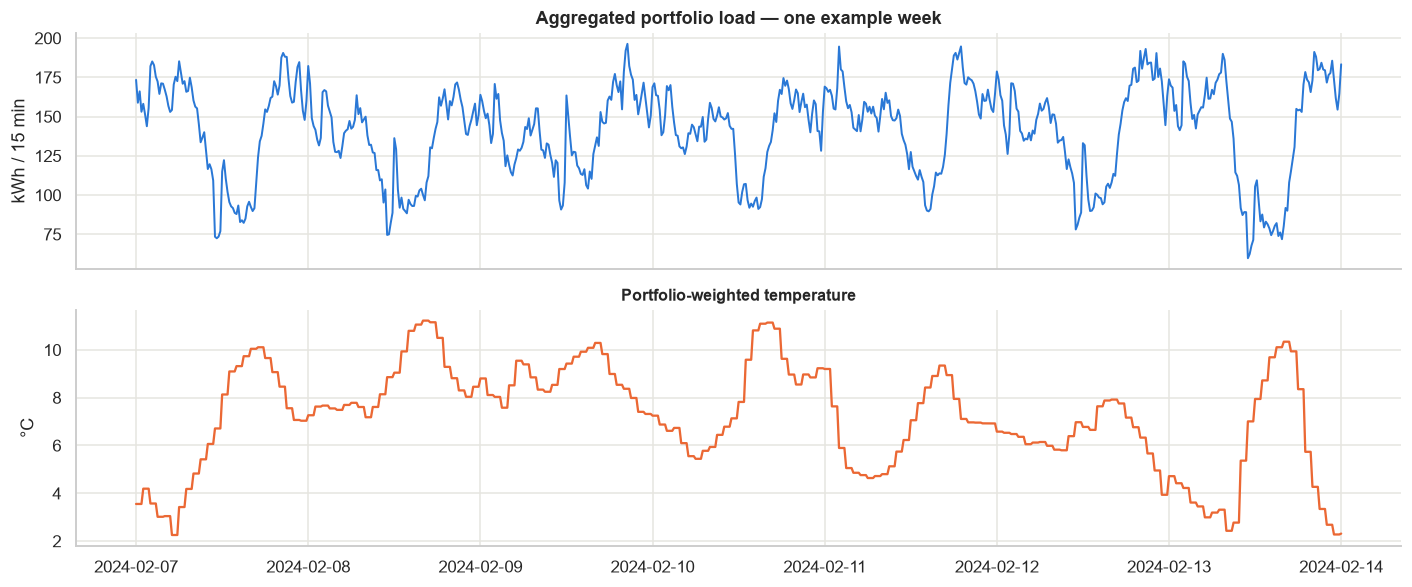

In [45]:
wk = df.loc[df.index[-STEPS * 21]: df.index[-STEPS * 14]]
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
axes[0].plot(wk.index, wk.total_kwh, color=C_BLUE, lw=1.3)
axes[0].set_ylabel("kWh / 15 min"); axes[0].set_title("Aggregated portfolio load — one example week")
axes[1].plot(wk.index, wk.temp, color=C_ORANGE, lw=1.5)
axes[1].set_ylabel("°C"); axes[1].set_title("Portfolio-weighted temperature", fontsize=10.5)
plt.tight_layout(); plt.show()

### 2.4 Day × quarter-hour matrices and data validity
Each day becomes one row of 96 quarter-hours. A day is **valid** as a forecast **target** if all 96 quarter-hours
have a load value (≥ `MIN_HOUSEHOLDS` reporting households, short gaps interpolated).

For the **history** (lag features, LSTM input, baseline) a separate, causal matrix is used: a missing quarter-hour is
replaced by the last observed value (≤ 2 h) or else by the same quarter-hour of the previous day. This matters
because the raw data contain no readings at all on the days the clocks go back (last Sunday of October); without
filling, that single day would also remove the following week (lags need 7 days of history).

In [46]:
day_index = pd.date_range(start_day, last_day, freq="D")
N_DAYS = len(day_index)
assert len(df) == N_DAYS * STEPS

def daymat(col):
    return pd.DataFrame(df[col].to_numpy(dtype=float).reshape(N_DAYS, STEPS), index=day_index)

Wx = {c: daymat(c) for c in WX_MAP.values()}
Ymat = daymat("mean_kwh")
day_ok = Ymat.notna().all(axis=1)
Ymat = Ymat.where(day_ok)                     # target matrix: invalid days -> NaN
Yhist = daymat("mean_kwh_hist").ffill(limit=1)   # causal history matrix: remaining gaps <- same quarter-hour of D-1
hist_ok = Yhist.notna().all(axis=1).astype(float)
usable = day_ok & (hist_ok.shift(1).rolling(7).sum() == 7)   # target day valid + 7 complete days of history
print(f"Days: {N_DAYS} | valid: {day_ok.sum()} | usable as target (incl. 7-day history): {usable.sum()}")
print("Invalid days:", [f"{d:%Y-%m-%d}" for d in day_index[~day_ok]])

Days: 1211 | valid: 1205 | usable as target (incl. 7-day history): 1198
Invalid days: ['2020-12-20', '2020-12-21', '2022-10-30', '2022-10-31', '2023-10-29', '2023-10-30']


### 2.5 Feature engineering
One row per **(target day D, quarter-hour t)**. **Every feature is available at 24:00 of D-1**: load and weather
lags come from D-1 or earlier, calendar features of day D are deterministic.

In [47]:
def ch_holidays(years):
    # Swiss national / widespread public holidays
    out = set()
    for y in years:
        e = pd.Timestamp(easter(y))
        out |= {pd.Timestamp(y, 1, 1), pd.Timestamp(y, 1, 2), e - pd.Timedelta(days=2), e + pd.Timedelta(days=1),
                e + pd.Timedelta(days=39), e + pd.Timedelta(days=50), pd.Timestamp(y, 8, 1),
                pd.Timestamp(y, 12, 25), pd.Timestamp(y, 12, 26)}
    return out

HOLIDAYS = ch_holidays(range(day_index[0].year, day_index[-1].year + 1))
naive_days = day_index.tz_localize(None)
flat = lambda m: np.asarray(m, dtype=float).ravel()          # (days, 96) -> day-major vector
per_day = lambda s: np.repeat(np.asarray(s, dtype=float), STEPS)
slot = np.tile(np.arange(STEPS), N_DAYS)

tab = pd.DataFrame(index=pd.MultiIndex.from_product([day_index, range(STEPS)], names=["day", "slot"]))
tab["y"] = flat(Ymat)
# ---- load lags (all from D-1 or earlier)
tab["lag_1d"] = flat(Yhist.shift(1))
tab["lag_2d"] = flat(Yhist.shift(2))
tab["lag_7d"] = flat(Yhist.shift(7))
tab["lag_1d_mean"] = per_day(Yhist.mean(axis=1).shift(1))
tab["lag_7d_mean"] = per_day(Yhist.mean(axis=1).rolling(7).mean().shift(1))
tab["lag_1d_max"] = per_day(Yhist.max(axis=1).shift(1))
tab["last_value"] = per_day(Yhist[STEPS - 1].shift(1))
# ---- weather measured up to 23:00 of D-1 (no information about the weather of day D)
t_mean = Wx["temp"].mean(axis=1)
tab["temp_lag_1d"] = flat(Wx["temp"].shift(1))
tab["sunshine_lag_1d"] = flat(Wx["sunshine"].shift(1))
tab["temp_mean_prev_d"] = per_day(t_mean.shift(1))
tab["temp_min_prev_d"] = per_day(Wx["temp"].min(axis=1).shift(1))
tab["temp_max_prev_d"] = per_day(Wx["temp"].max(axis=1).shift(1))
tab["hdd_prev_d"] = per_day((20 - t_mean).where(t_mean < 12, 0).where(t_mean.notna()).shift(1))
tab["sunshine_prev_d"] = per_day((Wx["sunshine"].sum(axis=1, min_count=STEPS) / 4).shift(1))
tab["humidity_prev_d"] = per_day(Wx["humidity"].mean(axis=1).shift(1))
tab["wind_prev_d"] = per_day(Wx["wind"].mean(axis=1).shift(1))
tab["temp_last"] = per_day(Wx["temp"][STEPS - 1].shift(1))
tab["temp_trend"] = per_day((t_mean - t_mean.shift(1)).shift(1))
tab["temp_mean_7d"] = per_day(t_mean.rolling(7).mean().shift(1))
# ---- calendar
dow = naive_days.dayofweek.to_numpy()
tab["slot"] = slot
tab["hour"] = slot // 4
tab["tod_sin"], tab["tod_cos"] = np.sin(2 * np.pi * slot / STEPS), np.cos(2 * np.pi * slot / STEPS)
tab["dow"] = per_day(dow)
tab["dow_sin"], tab["dow_cos"] = per_day(np.sin(2 * np.pi * dow / 7)), per_day(np.cos(2 * np.pi * dow / 7))
tab["is_weekend"] = per_day(dow >= 5)
tab["is_holiday"] = per_day(naive_days.isin(HOLIDAYS))
tab["is_xmas"] = per_day(((naive_days.month == 12) & (naive_days.day >= 24)) | ((naive_days.month == 1) & (naive_days.day <= 6)))
doy = naive_days.dayofyear.to_numpy()
tab["doy_sin"], tab["doy_cos"] = per_day(np.sin(2 * np.pi * doy / 365.25)), per_day(np.cos(2 * np.pi * doy / 365.25))
tab["is_dst"] = per_day([pd.Timestamp(f"{d:%Y-%m-%d} 12:00", tz="Europe/Zurich").dst() != pd.Timedelta(0) for d in naive_days])
# ---- bookkeeping (not features)
tab["n_contract"] = per_day(n_contract.reindex(day_index))                 # true portfolio size of D (target only)
tab["n_contract_prev"] = per_day(n_contract.reindex(day_index).shift(1))  # portfolio size known at forecast time
tab["total"] = tab.y * tab.n_contract
tab["baseline_total"] = flat(Yhist.shift(7)) * per_day(n_contract.reindex(day_index).shift(7))

LAG_COLS = ["lag_1d", "lag_2d", "lag_7d", "lag_1d_mean", "lag_7d_mean", "lag_1d_max", "last_value"]
WX_PAST_COLS = ["temp_lag_1d", "sunshine_lag_1d", "temp_mean_prev_d", "temp_min_prev_d", "temp_max_prev_d",
                "hdd_prev_d", "sunshine_prev_d", "humidity_prev_d", "wind_prev_d", "temp_last", "temp_trend",
                "temp_mean_7d"]
CAL_COLS = ["slot", "tod_sin", "tod_cos", "dow", "dow_sin", "dow_cos", "is_weekend", "is_holiday", "is_xmas",
            "doy_sin", "doy_cos", "is_dst"]
FEATURES = LAG_COLS + WX_PAST_COLS + CAL_COLS
print(f"{len(FEATURES)} features | table shape {tab.shape}")

31 features | table shape (116256, 37)


In [48]:
FEATURE_DOC = {
    "lag_1d": "load at the same quarter-hour on D-1", "lag_2d": "load at the same quarter-hour on D-2",
    "lag_7d": "load at the same quarter-hour on D-7", "lag_1d_mean": "mean load of D-1",
    "lag_7d_mean": "mean load of D-7 … D-1", "lag_1d_max": "peak load of D-1", "last_value": "load 23:45–24:00 on D-1",
    "temp_lag_1d": "temperature at the same quarter-hour on D-1", "sunshine_lag_1d": "sunshine at the same quarter-hour on D-1",
    "temp_mean_prev_d": "mean temperature of D-1", "temp_min_prev_d": "min temperature of D-1",
    "temp_max_prev_d": "max temperature of D-1", "hdd_prev_d": "heating degrees SIA 12/20 of D-1",
    "sunshine_prev_d": "sunshine hours of D-1", "humidity_prev_d": "mean rel. humidity of D-1",
    "wind_prev_d": "mean wind speed of D-1", "temp_last": "temperature of the last hour of D-1 (23:00)",
    "temp_trend": "mean temperature D-1 minus D-2", "temp_mean_7d": "mean temperature of D-7 … D-1",
    "slot": "quarter-hour of day (0–95)",
    "tod_sin": "time of day (sin)", "tod_cos": "time of day (cos)", "dow": "day of week (0=Mon)",
    "dow_sin": "day of week (sin)", "dow_cos": "day of week (cos)", "is_weekend": "Saturday / Sunday",
    "is_holiday": "Swiss public holiday", "is_xmas": "Christmas / New-Year period (24.12.–6.1.)",
    "doy_sin": "day of year (sin)", "doy_cos": "day of year (cos)", "is_dst": "summer time in Switzerland",
}
group = lambda f: "load lag" if f in LAG_COLS else "past weather" if f in WX_PAST_COLS else "calendar"
pd.DataFrame({"group": [group(f) for f in FEATURES], "description": [FEATURE_DOC[f] for f in FEATURES]},
             index=pd.Index(FEATURES, name="feature"))

,group,description
feature,,
lag_1d,load lag,load at the same quarter-hour on D-1
lag_2d,load lag,load at the same quarter-hour on D-2
lag_7d,load lag,load at the same quarter-hour on D-7
lag_1d_mean,load lag,mean load of D-1
lag_7d_mean,load lag,mean load of D-7 … D-1
lag_1d_max,load lag,peak load of D-1
last_value,load lag,load 23:45–24:00 on D-1
temp_lag_1d,past weather,temperature at the same quarter-hour on D-1
sunshine_lag_1d,past weather,sunshine at the same quarter-hour on D-1


### 2.6 Train / test split (80 / 20, chronological)

In [49]:
row_ok = tab[FEATURES + ["y", "total", "baseline_total", "n_contract_prev"]].notna().all(axis=1)
day_complete = row_ok.groupby(level="day").all()
model_days = day_index[(day_complete.reindex(day_index).fillna(False) & usable).to_numpy()]
n_test = int(round(len(model_days) * TEST_SHARE))
train_days, test_days = model_days[:-n_test], model_days[-n_test:]

data = tab.loc[model_days]
train, test = data.loc[train_days], data.loc[test_days]
X_train, y_train = train[FEATURES], train.y.to_numpy()
X_test, y_test = test[FEATURES], test.y.to_numpy()

# expanding-window CV folds over *days* inside the training period (used for all hyperparameter searches)
train_day_pos = pd.Series(np.arange(len(train_days)), index=train_days)
row_pos = train_day_pos.reindex(train.index.get_level_values("day")).to_numpy()
folds = [(np.flatnonzero(np.isin(row_pos, tr)), np.flatnonzero(np.isin(row_pos, va)))
         for tr, va in TimeSeriesSplit(n_splits=N_FOLDS).split(np.arange(len(train_days)))]

split_tab = pd.DataFrame({
    "days": [len(train_days), len(test_days)],
    "from": [train_days[0].date(), test_days[0].date()], "to": [train_days[-1].date(), test_days[-1].date()],
    "rows (day × 96)": [len(train), len(test)],
    "mean load / household [kWh/15min]": [y_train.mean(), y_test.mean()],
}, index=["train (80%)", "test (20%)"])
display(split_tab)
for k, (tr, va) in enumerate(folds):
    d_tr, d_va = train_days[np.unique(row_pos[tr])], train_days[np.unique(row_pos[va])]
    print(f"CV fold {k + 1}: train {d_tr[0]:%Y-%m-%d} → {d_tr[-1]:%Y-%m-%d} ({len(d_tr)} d) | "
          f"validate {d_va[0]:%Y-%m-%d} → {d_va[-1]:%Y-%m-%d} ({len(d_va)} d)")

,days,from,to,rows (day × 96),mean load / household [kWh/15min]
train (80%),958,2020-11-11,2023-06-30,91968,0.3252
test (20%),240,2023-07-01,2024-02-27,23040,0.2969


CV fold 1: train 2020-11-11 → 2021-07-11 (241 d) | validate 2021-07-12 → 2022-03-07 (239 d)
CV fold 2: train 2020-11-11 → 2022-03-07 (480 d) | validate 2022-03-08 → 2022-11-03 (239 d)
CV fold 3: train 2020-11-11 → 2022-11-03 (719 d) | validate 2022-11-04 → 2023-06-30 (239 d)


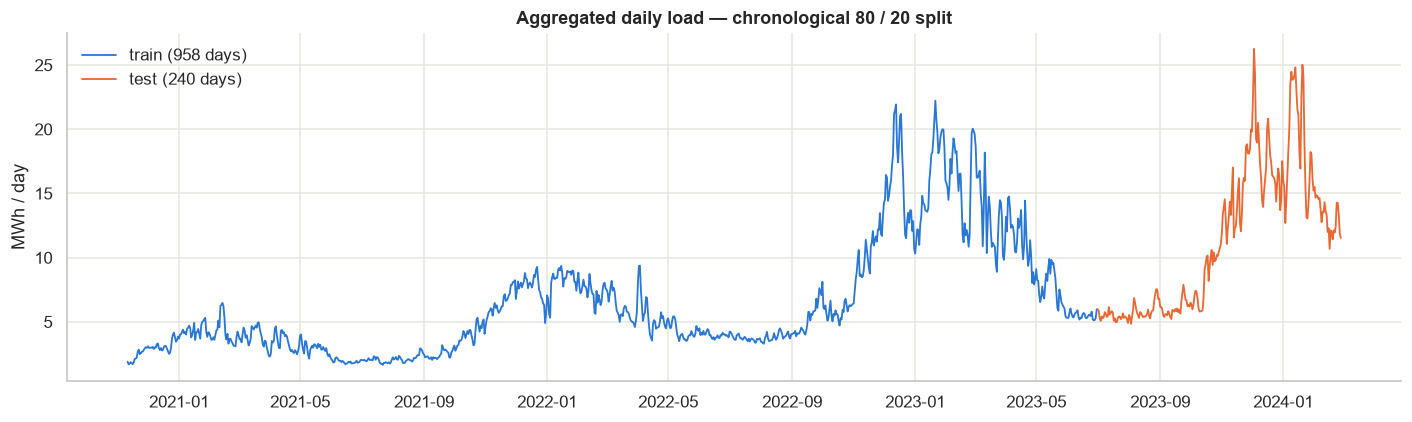

In [50]:
fig, ax = plt.subplots(figsize=(13, 4))
dtr = train.total.groupby(level="day").sum() / 1000
dte = test.total.groupby(level="day").sum() / 1000
ax.plot(dtr.index, dtr, color=C_BLUE, lw=1.2, label=f"train ({len(train_days)} days)")
ax.plot(dte.index, dte, color=C_ORANGE, lw=1.2, label=f"test ({len(test_days)} days)")
ax.set_ylabel("MWh / day"); ax.set_title("Aggregated daily load — chronological 80 / 20 split"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 3. Feature importance analysis
All analyses in this section use **only the training period**: an inner split puts the last 20% of the training
days aside as validation data, so the test set stays untouched.

In [51]:
n_inner_va = int(round(len(train_days) * 0.2))
inner_tr_days, inner_va_days = train_days[:-n_inner_va], train_days[-n_inner_va:]
itr, iva = train.loc[inner_tr_days], train.loc[inner_va_days]
print(f"inner train {inner_tr_days[0]:%Y-%m-%d} → {inner_tr_days[-1]:%Y-%m-%d} | "
      f"inner validation {inner_va_days[0]:%Y-%m-%d} → {inner_va_days[-1]:%Y-%m-%d}")

inner train 2020-11-11 → 2022-12-20 | inner validation 2022-12-21 → 2023-06-30


### 3.1 Correlation with the target

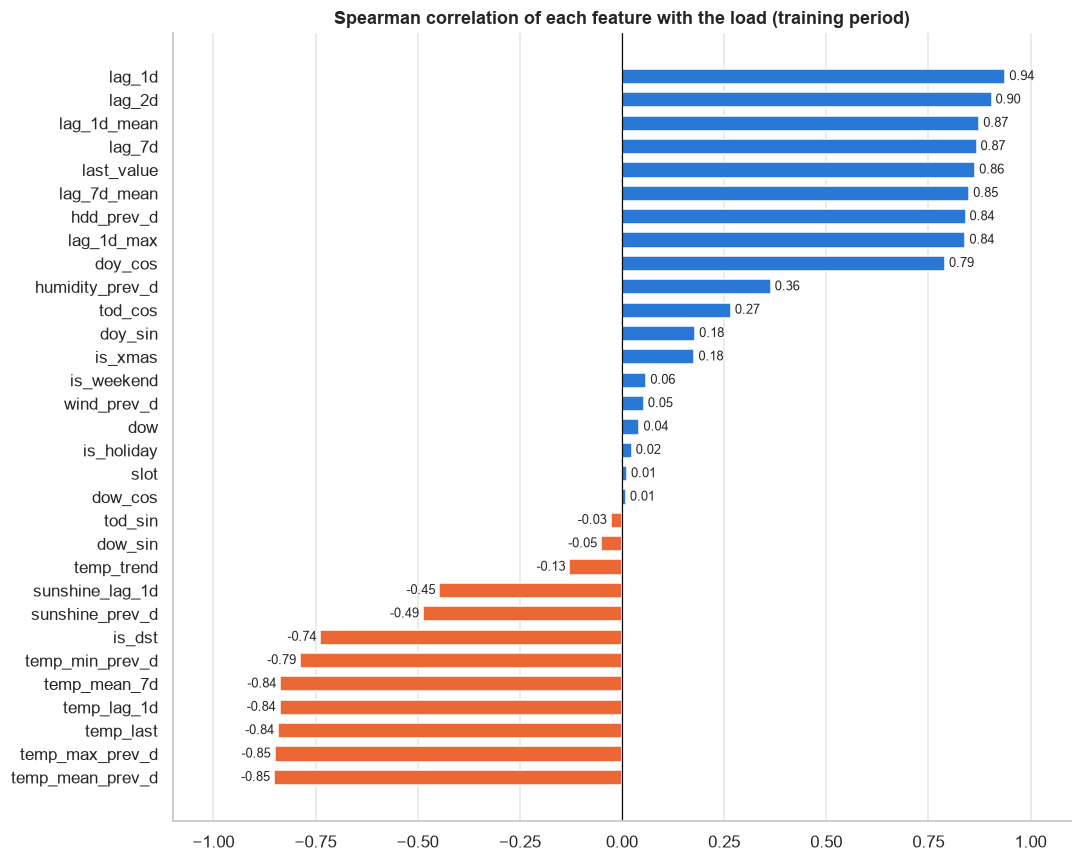

In [52]:
corr = train[FEATURES + ["y"]].corr(method="spearman")["y"].drop("y").sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(corr.index, corr.values, color=[C_ORANGE if v < 0 else C_BLUE for v in corr.values], height=.65)
for i, v in enumerate(corr.values):
    ax.text(v, i, f" {v:.2f} ", va="center", ha="left" if v >= 0 else "right", fontsize=8.5)
ax.axvline(0, color=C_INK, lw=.8); ax.set_xlim(-1.1, 1.1); ax.grid(axis="y", visible=False)
ax.set_title("Spearman correlation of each feature with the load (training period)")
plt.tight_layout(); plt.show()

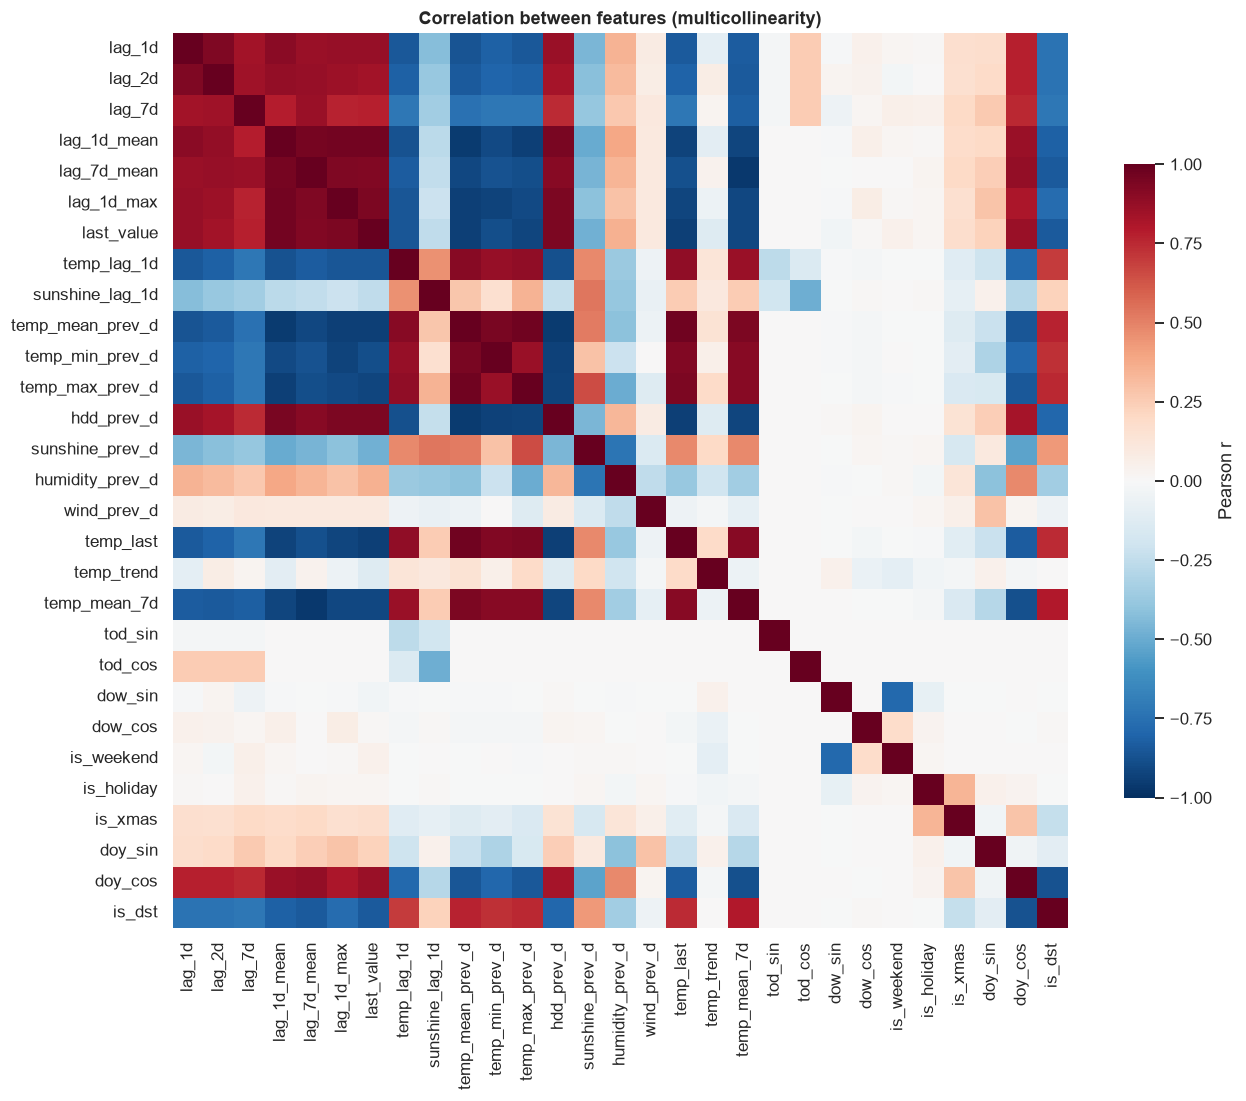

In [53]:
num = [f for f in FEATURES if f not in ("slot", "dow")]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(train[num].corr(), cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True, ax=ax,
            cbar_kws={"shrink": .7, "label": "Pearson r"})
ax.set_title("Correlation between features (multicollinearity)")
plt.tight_layout(); plt.show()

The lag features are strongly correlated with each other and with temperature/heating degrees (cold days follow cold
days). This **multicollinearity** makes linear-regression coefficients unstable (→ ridge regularisation) and splits
importance between correlated features in tree models.

### 3.2 Random-forest importance: impurity vs. permutation
*Impurity importance* is computed during training (biased towards high-cardinality features);
*permutation importance* measures how much the validation MAE increases when one feature is shuffled.

Inner-validation MAE of this reference forest: 0.0380 kWh / household / 15 min


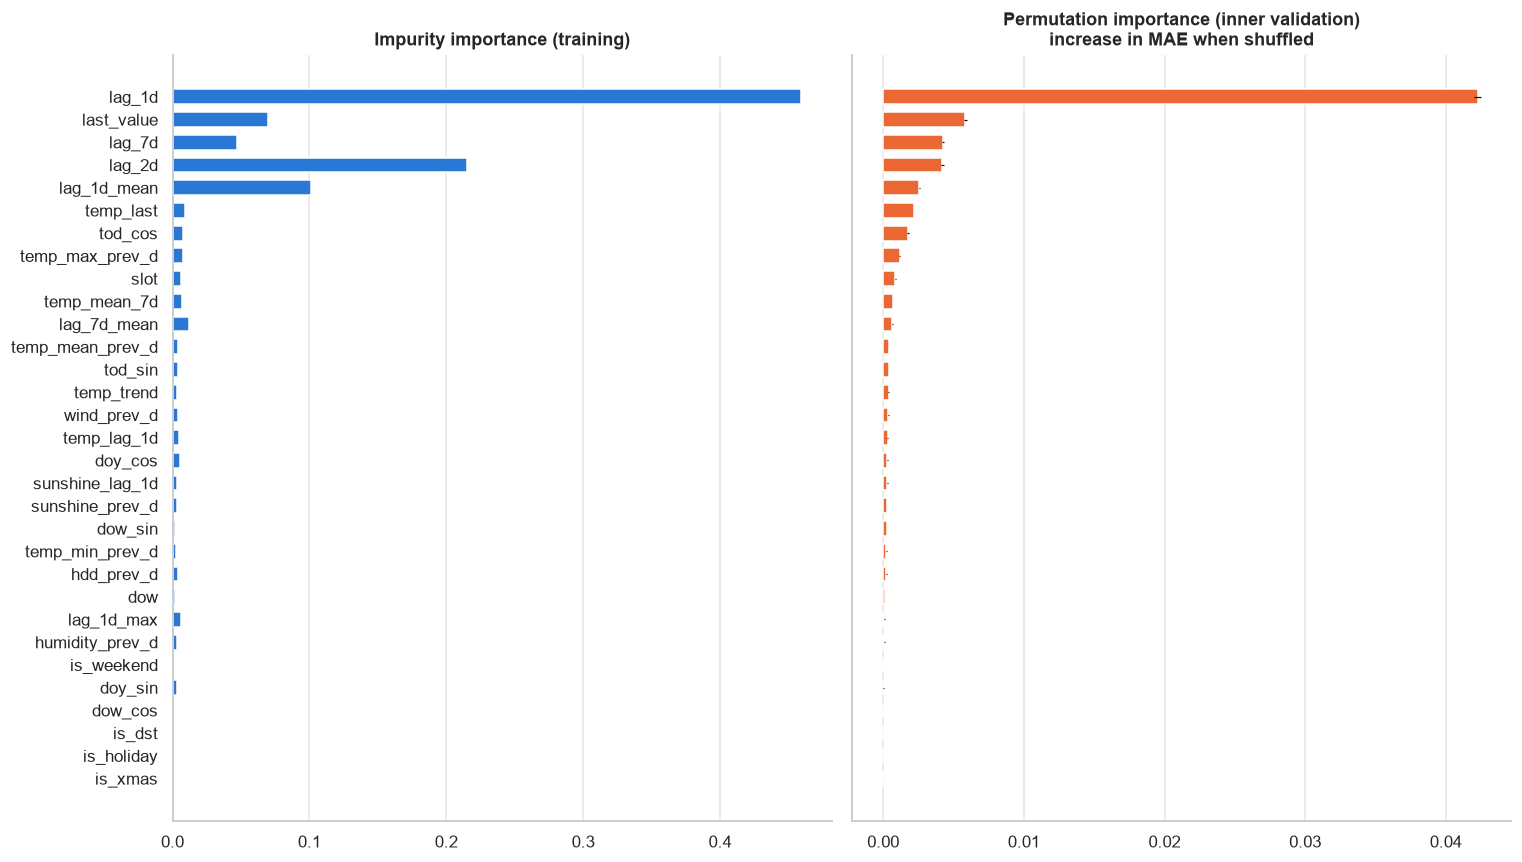

In [54]:
rf_fi = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=SEED)
rf_fi.fit(itr[FEATURES], itr.y)
mae_fi = np.abs(rf_fi.predict(iva[FEATURES]) - iva.y).mean()
perm = permutation_importance(rf_fi, iva[FEATURES], iva.y, scoring="neg_mean_absolute_error",
                              n_repeats=5, random_state=SEED)
imp = pd.DataFrame({"impurity": rf_fi.feature_importances_,
                    "permutation_mean": perm.importances_mean, "permutation_std": perm.importances_std},
                   index=FEATURES).sort_values("permutation_mean")
print(f"Inner-validation MAE of this reference forest: {mae_fi:.4f} kWh / household / 15 min")

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
axes[0].barh(imp.index, imp.impurity, color=C_BLUE, height=.65)
axes[0].set_title("Impurity importance (training)")
axes[1].barh(imp.index, imp.permutation_mean, xerr=imp.permutation_std, color=C_ORANGE, height=.65,
             error_kw=dict(ecolor=C_INK, lw=.8))
axes[1].set_title("Permutation importance (inner validation)\nincrease in MAE when shuffled")
for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### 3.3 Linear model: standardised coefficients
Coefficients of a ridge regression on standardised features — the sign shows the direction of the effect,
the magnitude its strength (to be read with care given the multicollinearity above).

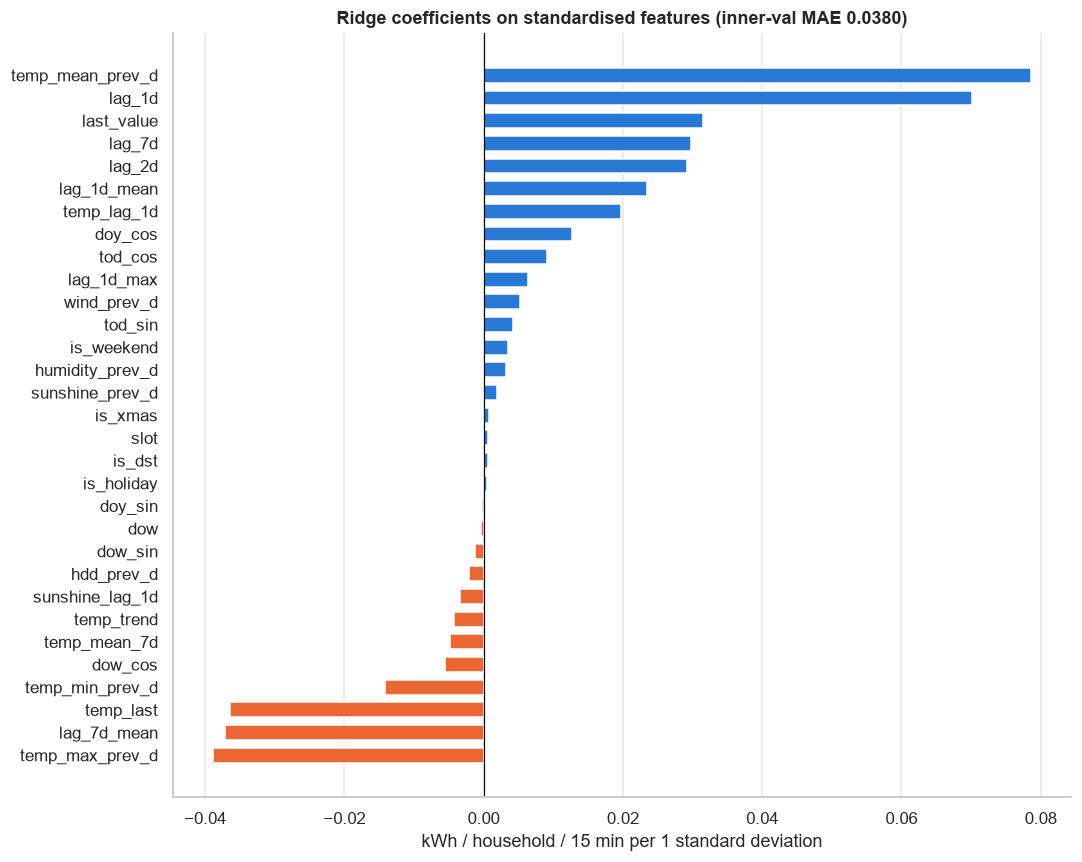

In [55]:
lin_fi = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(itr[FEATURES], itr.y)
coef = pd.Series(lin_fi[-1].coef_, index=FEATURES).sort_values()
mae_lin_fi = np.abs(lin_fi.predict(iva[FEATURES]) - iva.y).mean()
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coef.index, coef.values, color=[C_ORANGE if v < 0 else C_BLUE for v in coef.values], height=.65)
ax.axvline(0, color=C_INK, lw=.8); ax.grid(axis="y", visible=False)
ax.set_title(f"Ridge coefficients on standardised features (inner-val MAE {mae_lin_fi:.4f})")
ax.set_xlabel("kWh / household / 15 min per 1 standard deviation")
plt.tight_layout(); plt.show()

### 3.4 Importance by feature group
Drop-group experiment: retrain the reference forest without one feature group and measure the change in validation MAE.

,features,inner-val MAE,Δ MAE vs all [%]
model,,,
all features,31,0.0380,0.0000
without load lags,24,0.0453,19.0802
without past weather,19,0.0385,1.2890
without calendar,19,0.0395,3.8138


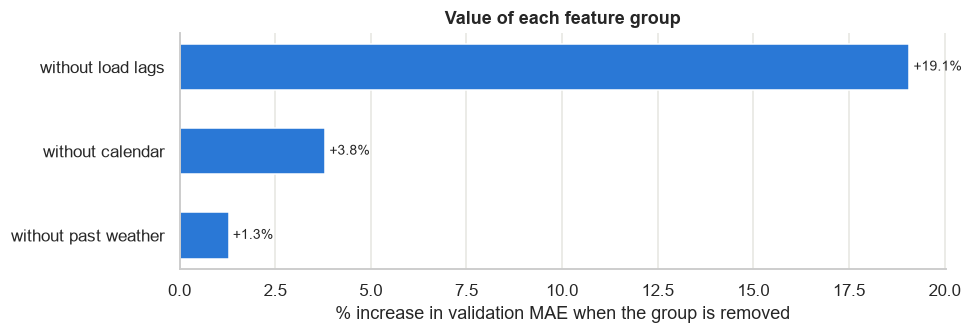

In [56]:
groups = {"load lags": LAG_COLS, "past weather": WX_PAST_COLS, "calendar": CAL_COLS}
rows = [{"model": "all features", "features": len(FEATURES), "inner-val MAE": mae_fi}]
for g, cols in groups.items():
    feats = [f for f in FEATURES if f not in cols]
    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=SEED)
    m.fit(itr[feats], itr.y)
    rows.append({"model": f"without {g}", "features": len(feats),
                 "inner-val MAE": np.abs(m.predict(iva[feats]) - iva.y).mean()})
grp = pd.DataFrame(rows).set_index("model")
grp["Δ MAE vs all [%]"] = 100 * (grp["inner-val MAE"] / mae_fi - 1)
display(grp)

fig, ax = plt.subplots(figsize=(9, 3.2))
g2 = grp.iloc[1:]["Δ MAE vs all [%]"].sort_values()
ax.barh(g2.index, g2.values, color=C_BLUE, height=.55)
for i, v in enumerate(g2.values):
    ax.text(v, i, f" {v:+.1f}%", va="center", fontsize=9)
ax.set_xlabel("% increase in validation MAE when the group is removed"); ax.grid(axis="y", visible=False)
ax.set_title("Value of each feature group")
plt.tight_layout(); plt.show()

### 3.5 Take-aways for modelling
FI_TAKEAWAYS_PLACEHOLDER

## 4. Hyperparameter optimisation & model training
Shared helpers: metrics, parameter persistence.

In [57]:
BEST_FILE = CACHE / "best_params.json"
best_params = json.loads(BEST_FILE.read_text()) if BEST_FILE.exists() else {}
if not RUN_HPO:
    assert best_params, "RUN_HPO=False needs data/_cache/best_params.json from a previous run"

def save_best():
    BEST_FILE.write_text(json.dumps(best_params, indent=2))

def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))

def cv_mae(make_model, X, y, feats):
    # mean validation MAE over the expanding-window folds
    return float(np.mean([mae(y[va], make_model().fit(X.iloc[tr][feats], y[tr]).predict(X.iloc[va][feats]))
                          for tr, va in folds]))

timings = {}

### 4.1 Baseline — same quarter-hour 7 days earlier
No parameters, no training: `forecast_total(D, t) = total(D-7, t)`. It captures the weekly rhythm but ignores
weather changes during the last week.

In [58]:
pred_total = {}                                         # model -> (n_test_days, 96) forecast of the aggregated load
actual_total = test.total.to_numpy().reshape(-1, STEPS)
n_contract_test = test.n_contract_prev.to_numpy().reshape(-1, STEPS)     # portfolio size known at 24:00 of D-1
pred_total["Baseline (t-7d)"] = test.baseline_total.to_numpy().reshape(-1, STEPS)
print("Baseline test MAE:", f"{mae(actual_total, pred_total['Baseline (t-7d)']):.2f} kWh per 15 min (aggregated)")

Baseline test MAE: 22.89 kWh per 15 min (aggregated)


### 4.2 Linear regression (ridge)
Linear model on all features; `hour` and `day of week` are one-hot encoded so the model can represent the daily
profile, numeric features are standardised. The only hyperparameter is the L2 penalty `alpha`
(`alpha → 0` = ordinary least squares), selected by 3-fold expanding-window CV.

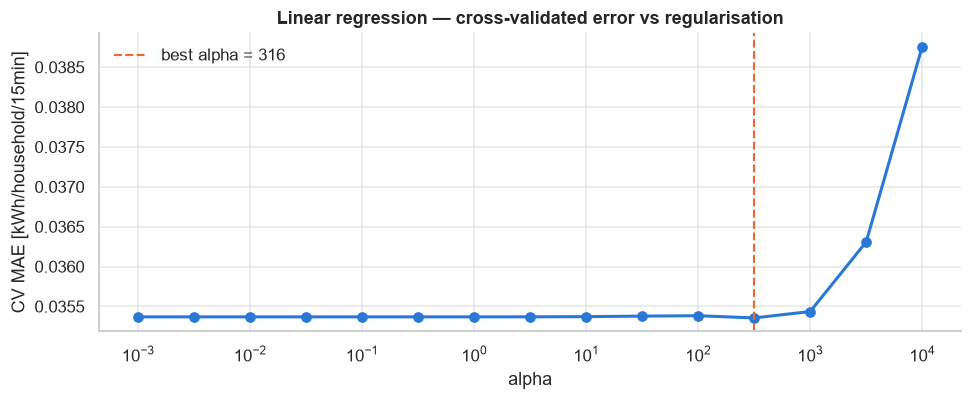

In [59]:
LR_NUM = [f for f in FEATURES if f not in ("slot", "dow")]
LR_CAT = ["hour", "dow"]

def make_lr(alpha):
    pre = ColumnTransformer([("num", StandardScaler(), LR_NUM),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), LR_CAT)])
    return make_pipeline(pre, Ridge(alpha=alpha))

X_train_lr = train[LR_NUM + LR_CAT]
alphas = np.logspace(-3, 4, 15)
if RUN_HPO:
    t0 = time.time()
    lr_cv = pd.Series([cv_mae(lambda a=a: make_lr(a), X_train_lr, y_train, LR_NUM + LR_CAT) for a in alphas], index=alphas)
    best_params["linear"] = {"alpha": float(lr_cv.idxmin())}
    best_params["linear_cv"] = {"alphas": alphas.tolist(), "cv_mae": lr_cv.tolist()}
    save_best()
    timings["linear HPO"] = time.time() - t0
lr_cv = pd.Series(best_params["linear_cv"]["cv_mae"], index=best_params["linear_cv"]["alphas"])

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(lr_cv.index, lr_cv.values, marker="o", ms=6, color=C_BLUE)
ax.axvline(best_params["linear"]["alpha"], color=C_ORANGE, ls="--", lw=1.4, label=f"best alpha = {best_params['linear']['alpha']:.3g}")
ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_ylabel("CV MAE [kWh/household/15min]")
ax.set_title("Linear regression — cross-validated error vs regularisation"); ax.legend()
plt.tight_layout(); plt.show()

t0 = time.time()
lr_model = make_lr(best_params["linear"]["alpha"]).fit(X_train_lr, y_train)
timings["linear fit"] = time.time() - t0
pred_lr = lr_model.predict(test[LR_NUM + LR_CAT]).reshape(-1, STEPS)
pred_total["Linear regression"] = pred_lr * n_contract_test

### 4.3 Random forest
Hyperparameters are searched with **Optuna** (TPE sampler) minimising the mean MAE over the same 3 expanding-window folds.

In [60]:
def rf_from(p, **kw):
    return RandomForestRegressor(n_estimators=p["n_estimators"], max_depth=p["max_depth"],
                                 min_samples_leaf=p["min_samples_leaf"], max_features=p["max_features"],
                                 max_samples=p["max_samples"], n_jobs=-1, random_state=SEED, **kw)

def rf_objective(trial):
    p = {"n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
         "max_depth": trial.suggest_int("max_depth", 6, 40),
         "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50, log=True),
         "max_features": trial.suggest_float("max_features", 0.2, 1.0),
         "max_samples": trial.suggest_float("max_samples", 0.3, 1.0)}
    return cv_mae(lambda: rf_from(p), X_train, y_train, FEATURES)

if RUN_HPO:
    t0 = time.time()
    rf_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    rf_study.enqueue_trial({"n_estimators": 200, "max_depth": 20, "min_samples_leaf": 5, "max_features": 0.5, "max_samples": 0.8})
    rf_study.optimize(rf_objective, n_trials=N_TRIALS_RF)
    best_params["random_forest"] = rf_study.best_params
    best_params["random_forest_trials"] = rf_study.trials_dataframe()[["number", "value"] + [f"params_{k}" for k in rf_study.best_params]].to_dict("list")
    save_best()
    timings["random forest HPO"] = time.time() - t0
    print(f"{N_TRIALS_RF} trials in {timings['random forest HPO'] / 60:.1f} min")

rf_trials = pd.DataFrame(best_params["random_forest_trials"]).rename(columns=lambda c: c.replace("params_", ""))
print("Best parameters:", best_params["random_forest"])
display(rf_trials.sort_values("value").head(8).rename(columns={"value": "CV MAE"}))

3 trials in 0.8 min
Best parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_samples': 0.8}


,number,CV MAE,n_estimators,max_depth,min_samples_leaf,max_features,max_samples
0,0,0.0343,200,20,5,0.5000,0.8000
1,1,0.0343,200,39,15,0.6789,0.4092
2,2,0.0353,150,8,27,0.6809,0.7957


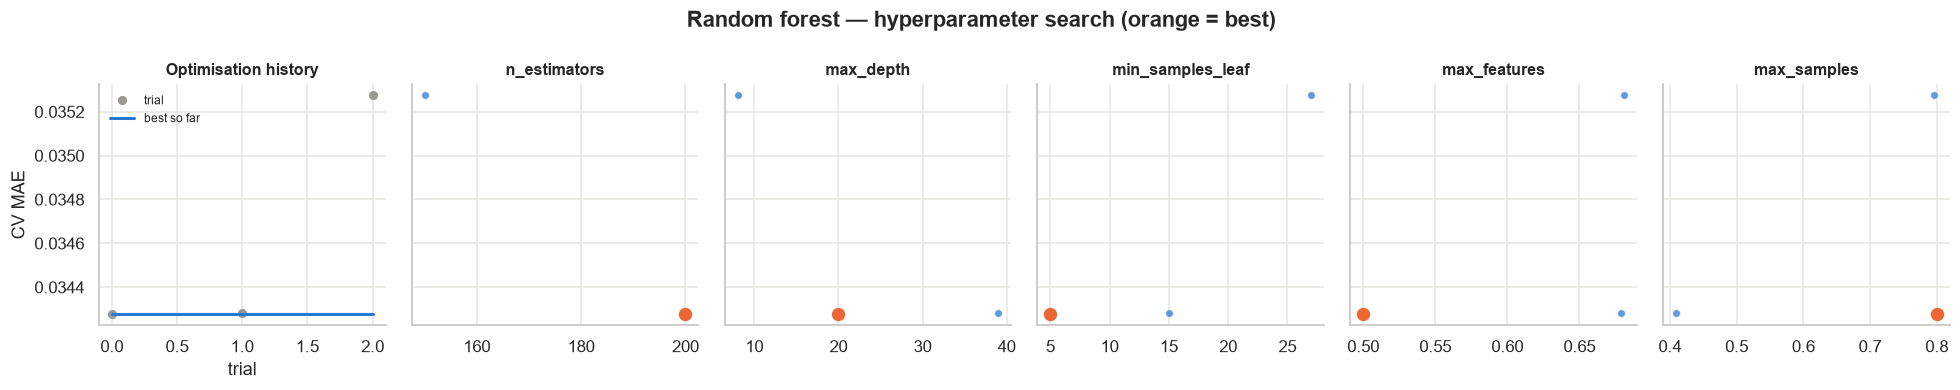

In [61]:
ps = list(best_params["random_forest"])
fig, axes = plt.subplots(1, len(ps) + 1, figsize=(18, 3.6))
axes[0].plot(rf_trials.number, rf_trials.value, "o", ms=5, color=C_GREY, label="trial")
axes[0].plot(rf_trials.number, rf_trials.value.cummin(), color=C_BLUE, label="best so far")
axes[0].set_title("Optimisation history", fontsize=10.5); axes[0].set_xlabel("trial"); axes[0].set_ylabel("CV MAE")
axes[0].legend(fontsize=8)
best_val = rf_trials.value.min()
for ax, p in zip(axes[1:], ps):
    ax.scatter(rf_trials[p], rf_trials.value, s=26, color=C_BLUE, alpha=.75, edgecolor="white", linewidth=.6)
    ax.scatter(best_params["random_forest"][p], best_val, s=60, color=C_ORANGE, zorder=3)
    ax.set_title(p, fontsize=10.5); ax.set_yticklabels([])
plt.suptitle("Random forest — hyperparameter search (orange = best)", fontweight="bold")
plt.tight_layout(); plt.show()

In [62]:
t0 = time.time()
rf_model = rf_from(best_params["random_forest"]).fit(X_train, y_train)
timings["random forest fit"] = time.time() - t0
pred_rf = rf_model.predict(X_test).reshape(-1, STEPS)
pred_total["Random forest"] = pred_rf * n_contract_test

print(f"Random forest trained in {timings['random forest fit']:.0f}s")

Random forest trained in 15s


### 4.4 LSTM (sequence-to-sequence)
**Architecture**
* **Encoder LSTM** runs over the **last 7 days, one step per day**. Each step sees that day's 24 hourly loads,
  24 hourly temperatures and a weekend/holiday flag.
* **Decoder LSTM** starts from the encoder's final state and runs over the **24 hours of day D**. Each step receives
  the features of its four quarter-hours (the same features as the tabular models: load lags, past weather,
  calendar of day D).
* A linear head turns every decoder step into **4 quarter-hour values** → 24 × 4 = 96 outputs in one shot
  (no recursive error accumulation).

Why not one recurrent step per quarter-hour? 7 × 96 + 96 = 768 sequential steps are ~20× slower to train on a CPU
for the same information; 7 + 24 = 31 steps keep the hyperparameter search feasible.

All inputs and the target are standardised with training statistics. Loss = MSE, optimiser = Adam, early stopping.

In [63]:
DEC_COLS = [f for f in FEATURES if f not in ("slot", "dow")]
Yh, Th = Yhist.to_numpy(), Wx["temp"].to_numpy()
day_pos_all = pd.Series(np.arange(N_DAYS), index=day_index)
offday_all = np.asarray((naive_days.dayofweek >= 5) | naive_days.isin(HOLIDAYS), dtype=float)

def build_arrays(days):
    P = day_pos_all.reindex(days).to_numpy()
    hist = P[:, None] + np.arange(-7, 0)[None, :]                              # positions of the 7 previous days
    load_h = Yh[hist].reshape(len(P), 7, 24, 4).mean(-1)                       # hourly mean load per day
    temp_h = Th[hist].reshape(len(P), 7, 24, 4).mean(-1)
    enc = np.concatenate([load_h, temp_h, offday_all[hist][..., None]], axis=-1)            # (n, 7, 49)
    sub = data.loc[days]
    dec = sub[DEC_COLS].to_numpy().reshape(len(P), 24, 4 * len(DEC_COLS))                   # (n, 24, 4·F)
    y = sub.y.to_numpy().reshape(len(P), STEPS)                                             # (n, 96)
    return enc, dec, y

class Scalers:
    # per-feature standardisation fitted on training days only
    def __init__(self, enc, dec, y):
        e, d = enc.reshape(-1, enc.shape[-1]), dec.reshape(-1, dec.shape[-1])
        self.e_mu, self.e_sd = e.mean(0), e.std(0) + 1e-8
        self.d_mu, self.d_sd = d.mean(0), d.std(0) + 1e-8
        self.y_mu, self.y_sd = y.mean(), y.std()
    def transform(self, enc, dec, y=None):
        out = [torch.tensor((enc - self.e_mu) / self.e_sd, dtype=torch.float32),
               torch.tensor((dec - self.d_mu) / self.d_sd, dtype=torch.float32)]
        if y is not None:
            out.append(torch.tensor((y - self.y_mu) / self.y_sd, dtype=torch.float32))
        return out
    def inverse_y(self, y_scaled):
        return y_scaled * self.y_sd + self.y_mu

class Seq2SeqLSTM(nn.Module):
    def __init__(self, n_enc, n_dec, hidden, layers, dropout):
        super().__init__()
        drop = dropout if layers > 1 else 0.0
        self.encoder = nn.LSTM(n_enc, hidden, layers, batch_first=True, dropout=drop)
        self.decoder = nn.LSTM(n_dec, hidden, layers, batch_first=True, dropout=drop)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 4))
    def forward(self, x_enc, x_dec):
        _, state = self.encoder(x_enc)                                         # summary of the last 7 days
        out, _ = self.decoder(x_dec, state)                                    # (batch, 24, hidden)
        return self.head(out).reshape(len(x_enc), -1)                          # (batch, 96)

def predict_lstm(model, tensors, scalers):
    model.eval()
    with torch.no_grad():
        return scalers.inverse_y(model(tensors[0], tensors[1]).numpy())

def fit_lstm(p, tr, scalers, va=None, epochs=LSTM_MAX_EPOCHS, seed=SEED, trial=None):
    # tr / va: lists of tensors [enc, dec, y_scaled]; va additionally needs y in kWh for the MAE
    torch.manual_seed(seed)
    model = Seq2SeqLSTM(tr[0].shape[-1], tr[1].shape[-1], p["hidden"], p["layers"], p["dropout"])
    opt = torch.optim.Adam(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    loader = DataLoader(TensorDataset(*tr), batch_size=p["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    loss_fn, hist, best, best_state, best_ep, wait = nn.MSELoss(), [], np.inf, None, epochs, 0
    for ep in range(epochs):
        model.train()
        tr_loss = 0.0
        for xe, xd, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xe, xd), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item() * len(yb)
        rec = {"epoch": ep + 1, "train_mse_scaled": tr_loss / len(tr[0])}
        if va is not None:
            rec["val_mae"] = mae(predict_lstm(model, va, scalers), va[3])
            if rec["val_mae"] < best - 1e-6:
                best, best_state, best_ep, wait = rec["val_mae"], copy.deepcopy(model.state_dict()), ep + 1, 0
            else:
                wait += 1
            if trial is not None:
                trial.report(rec["val_mae"], ep)
                if trial.should_prune():
                    raise optuna.TrialPruned()
        hist.append(rec)
        if va is not None and wait >= LSTM_PATIENCE:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(hist), best_ep

enc_tr, dec_tr, ylstm_tr = build_arrays(train_days)
enc_te, dec_te, ylstm_te = build_arrays(test_days)
print("encoder input", enc_tr.shape, "| decoder input", dec_tr.shape, "| target", ylstm_tr.shape)

encoder input (958, 7, 49) | decoder input (958, 24, 116) | target (958, 96)


**Hyperparameter search.** Training an LSTM is expensive, so instead of 3 folds the search uses the inner split
(last 20% of the training days as validation) with early stopping and Optuna's median pruner, which stops
unpromising trials early. The number of epochs of the best trial is reused for the final training on all training days.

In [64]:
in_tr = np.isin(train_days, inner_tr_days)
sc_inner = Scalers(enc_tr[in_tr], dec_tr[in_tr], ylstm_tr[in_tr])
T_in_tr = sc_inner.transform(enc_tr[in_tr], dec_tr[in_tr], ylstm_tr[in_tr])
T_in_va = sc_inner.transform(enc_tr[~in_tr], dec_tr[~in_tr]) + [None, ylstm_tr[~in_tr]]

def lstm_objective(trial):
    p = {"hidden": trial.suggest_categorical("hidden", [32, 64, 128]),
         "layers": trial.suggest_int("layers", 1, 2),
         "dropout": trial.suggest_float("dropout", 0.0, 0.4),
         "lr": trial.suggest_float("lr", 3e-4, 5e-3, log=True),
         "batch": trial.suggest_categorical("batch", [16, 32, 64]),
         "weight_decay": trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)}
    _, hist, best_ep = fit_lstm(p, T_in_tr, sc_inner, va=T_in_va, trial=trial)
    trial.set_user_attr("epochs", int(best_ep))
    trial.set_user_attr("curve", {"train": hist.train_mse_scaled.tolist(), "val": hist.val_mae.tolist()})
    return float(hist.val_mae.min())

if RUN_HPO:
    t0 = time.time()
    lstm_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
                                     pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=8))
    lstm_study.enqueue_trial({"hidden": 64, "layers": 1, "dropout": 0.1, "lr": 1e-3, "batch": 32, "weight_decay": 1e-5})
    lstm_study.optimize(lstm_objective, n_trials=N_TRIALS_LSTM)
    best_params["lstm"] = {**lstm_study.best_params, "epochs": lstm_study.best_trial.user_attrs["epochs"]}
    best_params["lstm_curve"] = lstm_study.best_trial.user_attrs["curve"]
    tdf = lstm_study.trials_dataframe()
    tdf["epochs"] = tdf.get("user_attrs_epochs")
    best_params["lstm_trials"] = tdf[["number", "value", "state", "epochs"] + [f"params_{k}" for k in lstm_study.best_params]].astype(str).to_dict("list")
    save_best()
    timings["LSTM HPO"] = time.time() - t0
    print(f"{N_TRIALS_LSTM} trials in {timings['LSTM HPO'] / 60:.1f} min")

lstm_trials = pd.DataFrame(best_params["lstm_trials"]).rename(columns=lambda c: c.replace("params_", ""))
lstm_trials["value"] = pd.to_numeric(lstm_trials.value, errors="coerce")
print("Best parameters:", best_params["lstm"])
display(lstm_trials.sort_values("value").head(8).rename(columns={"value": "val MAE"}))

3 trials in 0.1 min
Best parameters: {'hidden': 64, 'layers': 1, 'dropout': 0.1, 'lr': 0.001, 'batch': 32, 'weight_decay': 1e-05, 'epochs': 6}


,number,val MAE,state,epochs,hidden,layers,dropout,lr,batch,weight_decay
0,0,0.0433,COMPLETE,6,64,1,0.1,0.001,32,1e-05
2,2,0.0450,COMPLETE,6,64,1,0.07272998688284026,0.0005025899797991108,32,1.4618962793704944e-06
1,1,0.0464,COMPLETE,6,64,2,0.06240745617697461,0.00046528919170687577,32,6.796578090758147e-05


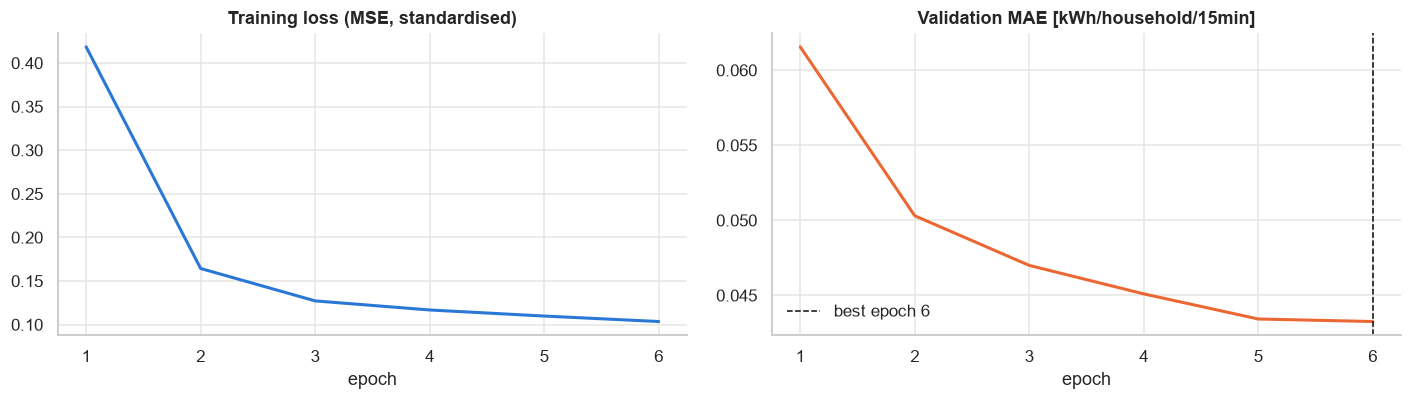

In [65]:
# learning curve of the best trial (inner split)
p_best = best_params["lstm"]
curve = best_params["lstm_curve"]
epochs_axis = np.arange(1, len(curve["val"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(epochs_axis, curve["train"], color=C_BLUE)
axes[0].set_title("Training loss (MSE, standardised)"); axes[0].set_xlabel("epoch")
axes[1].plot(epochs_axis, curve["val"], color=C_ORANGE)
axes[1].axvline(p_best["epochs"], color=C_INK, ls="--", lw=1, label=f"best epoch {p_best['epochs']}")
axes[1].set_title("Validation MAE [kWh/household/15min]"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

In [66]:
# final LSTM: train on all training days for the selected number of epochs, average several seeds
sc_full = Scalers(enc_tr, dec_tr, ylstm_tr)
T_tr = sc_full.transform(enc_tr, dec_tr, ylstm_tr)
T_te = sc_full.transform(enc_te, dec_te)
t0 = time.time()
lstm_models = [fit_lstm(p_best, T_tr, sc_full, epochs=p_best["epochs"], seed=SEED + k)[0] for k in range(LSTM_ENSEMBLE)]
timings["LSTM fit"] = time.time() - t0
pred_lstm = np.mean([predict_lstm(m, T_te, sc_full) for m in lstm_models], axis=0)
pred_total["LSTM"] = pred_lstm * n_contract_test
print(f"Trained {LSTM_ENSEMBLE} LSTM(s) for {p_best['epochs']} epochs in {timings['LSTM fit']:.0f}s")

Trained 1 LSTM(s) for 6 epochs in 2s


## 5. Validation on the test period (last 20%)
All forecasts are for the **aggregated load of all households** in kWh per 15 min, issued at 24:00 of the previous day.

| Metric | Meaning |
|---|---|
| MAE / RMSE | mean absolute / root-mean-square error per quarter-hour (kWh) |
| nMAE | MAE relative to the mean load (%) |
| MAPE | mean absolute percentage error per quarter-hour |
| R² | explained variance |
| Bias | mean error relative to mean load (+ = over-forecast) |
| Daily energy error | abs. error of the day's total energy (what is bought on the day-ahead market), % |
| Daily peak error | abs. error of the day's maximum quarter-hour load, % |
| Skill vs baseline | 1 − MAE / MAE(baseline) |

In [67]:
def evaluate(y, p):
    e = p - y
    return {"MAE [kWh]": np.abs(e).mean(), "RMSE [kWh]": np.sqrt((e ** 2).mean()),
            "nMAE [%]": 100 * np.abs(e).mean() / y.mean(), "MAPE [%]": 100 * np.mean(np.abs(e) / y),
            "R²": r2_score(y.ravel(), p.ravel()), "Bias [%]": 100 * e.mean() / y.mean(),
            "Daily energy error [%]": 100 * np.mean(np.abs(e.sum(1)) / y.sum(1)),
            "Daily peak error [%]": 100 * np.mean(np.abs(p.max(1) - y.max(1)) / y.max(1))}

MODELS = list(pred_total)
res = pd.DataFrame({m: evaluate(actual_total, pred_total[m]) for m in MODELS}).T
res["Skill vs baseline [%]"] = 100 * (1 - res["MAE [kWh]"] / res.loc["Baseline (t-7d)", "MAE [kWh]"])
display(res.style.format("{:.2f}").format("{:.3f}", subset=["R²"])
        .background_gradient(cmap="Blues_r", subset=["nMAE [%]", "Daily energy error [%]"]))

,MAE [kWh],RMSE [kWh],nMAE [%],MAPE [%],R²,Bias [%],Daily energy error [%],Daily peak error [%],Skill vs baseline [%]
Baseline (t-7d),22.89,33.96,19.46,18.11,0.717,-1.89,14.34,12.25,0.00
Linear regression,12.37,17.03,10.52,11.48,0.929,1.19,6.58,7.56,45.96
Random forest,11.63,16.44,9.89,10.60,0.934,1.39,6.11,6.77,49.17
LSTM,13.44,17.86,11.43,13.25,0.922,0.82,7.17,9.24,41.29


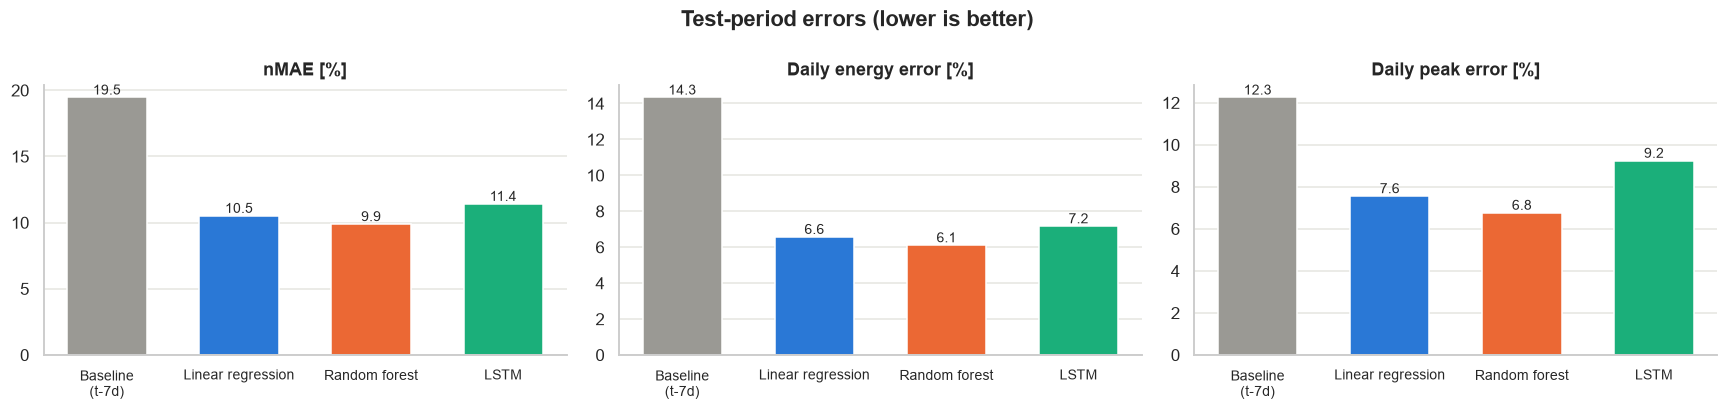

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, col in zip(axes, ["nMAE [%]", "Daily energy error [%]", "Daily peak error [%]"]):
    v = res.loc[MODELS, col]
    ax.bar(range(len(v)), v.values, color=[MODEL_COLORS[m] for m in MODELS], width=.6)
    for i, x in enumerate(v.values):
        ax.text(i, x, f"{x:.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(v)), [m.replace(" (", "\n(") for m in MODELS], fontsize=9)
    ax.set_title(col); ax.grid(axis="x", visible=False)
plt.suptitle("Test-period errors (lower is better)", fontweight="bold")
plt.tight_layout(); plt.show()

### 5.1 Generalisation check: training vs test error
A large gap between training and test error indicates over-fitting.

In [69]:
actual_tr = train.total.to_numpy().reshape(-1, STEPS)
nc_tr = train.n_contract_prev.to_numpy().reshape(-1, STEPS)
in_sample = {
    "Baseline (t-7d)": train.baseline_total.to_numpy().reshape(-1, STEPS),
    "Linear regression": lr_model.predict(train[LR_NUM + LR_CAT]).reshape(-1, STEPS) * nc_tr,
    "Random forest": rf_model.predict(X_train).reshape(-1, STEPS) * nc_tr,
    "LSTM": np.mean([predict_lstm(m, T_tr, sc_full) for m in lstm_models], axis=0) * nc_tr,
}
gap = pd.DataFrame({"train nMAE [%]": {m: evaluate(actual_tr, p)["nMAE [%]"] for m, p in in_sample.items()},
                    "test nMAE [%]": res.loc[MODELS, "nMAE [%]"]})
gap["gap [pp]"] = gap["test nMAE [%]"] - gap["train nMAE [%]"]
display(gap.round(2))

,train nMAE [%],test nMAE [%],gap [pp]
Baseline (t-7d),20.1400,19.4600,-0.6800
Linear regression,11.1600,10.5200,-0.6500
Random forest,4.4800,9.8900,5.4200
LSTM,11.2100,11.4300,0.2100


### 5.2 Example forecasts
Forecasts for four characteristic test days (coldest, a mild day, the warmest, and Christmas Day if it is in the test
period) and for a two-week stretch. The temperature in the titles is the *measured* mean of the target day — used
only to pick and label the days, it was not available to the models.

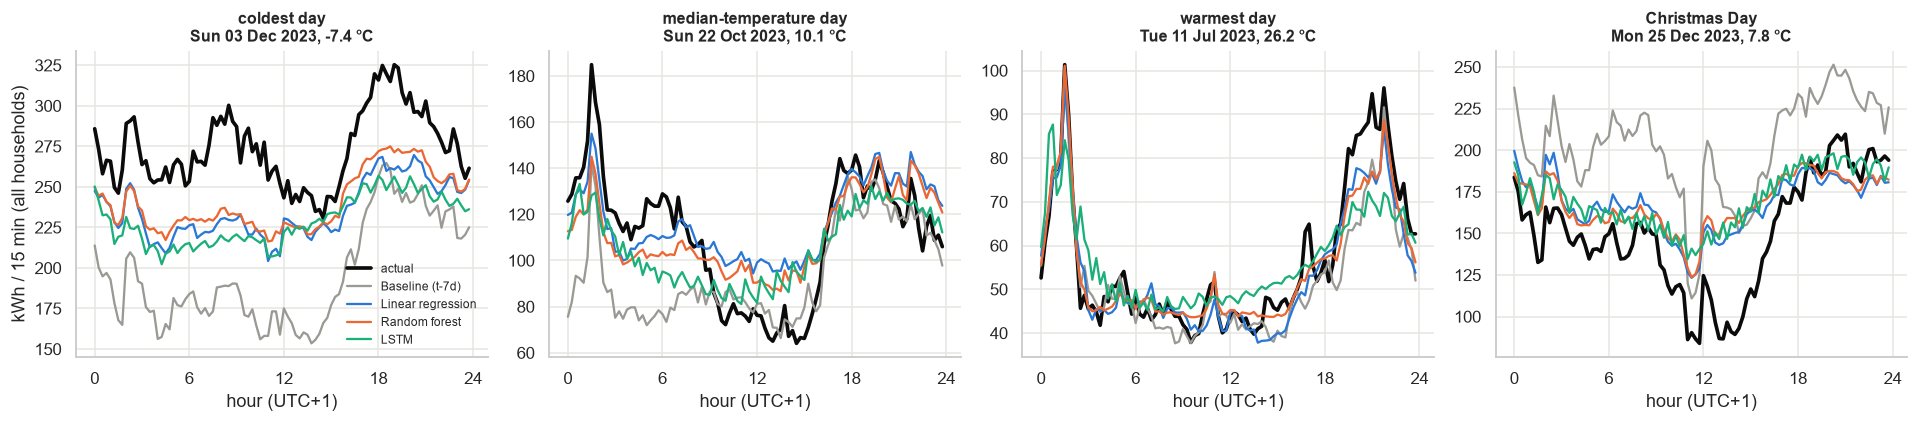

In [70]:
test_temp = Wx["temp"].mean(axis=1).reindex(test_days)        # evaluation only — not a model input
picks = {"coldest day": test_temp.idxmin(), "median-temperature day": (test_temp - test_temp.median()).abs().idxmin(),
         "warmest day": test_temp.idxmax()}
xmas = [d for d in test_days if d.month == 12 and d.day == 25]
if xmas:
    picks["Christmas Day"] = xmas[0]
hours = np.arange(STEPS) / 4
fig, axes = plt.subplots(1, len(picks), figsize=(4.4 * len(picks), 4), sharey=False)
for ax, (label, d) in zip(np.atleast_1d(axes), picks.items()):
    i = test_days.get_loc(d)
    ax.plot(hours, actual_total[i], color=C_INK, lw=2.4, label="actual")
    for m in MODELS:
        ax.plot(hours, pred_total[m][i], color=MODEL_COLORS[m], lw=1.5, label=m)
    ax.set_title(f"{label}\n{d:%a %d %b %Y}, {test_temp[d]:.1f} °C", fontsize=10.5)
    ax.set_xticks(range(0, 25, 6)); ax.set_xlabel("hour (UTC+1)")
np.atleast_1d(axes)[0].set_ylabel("kWh / 15 min (all households)")
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

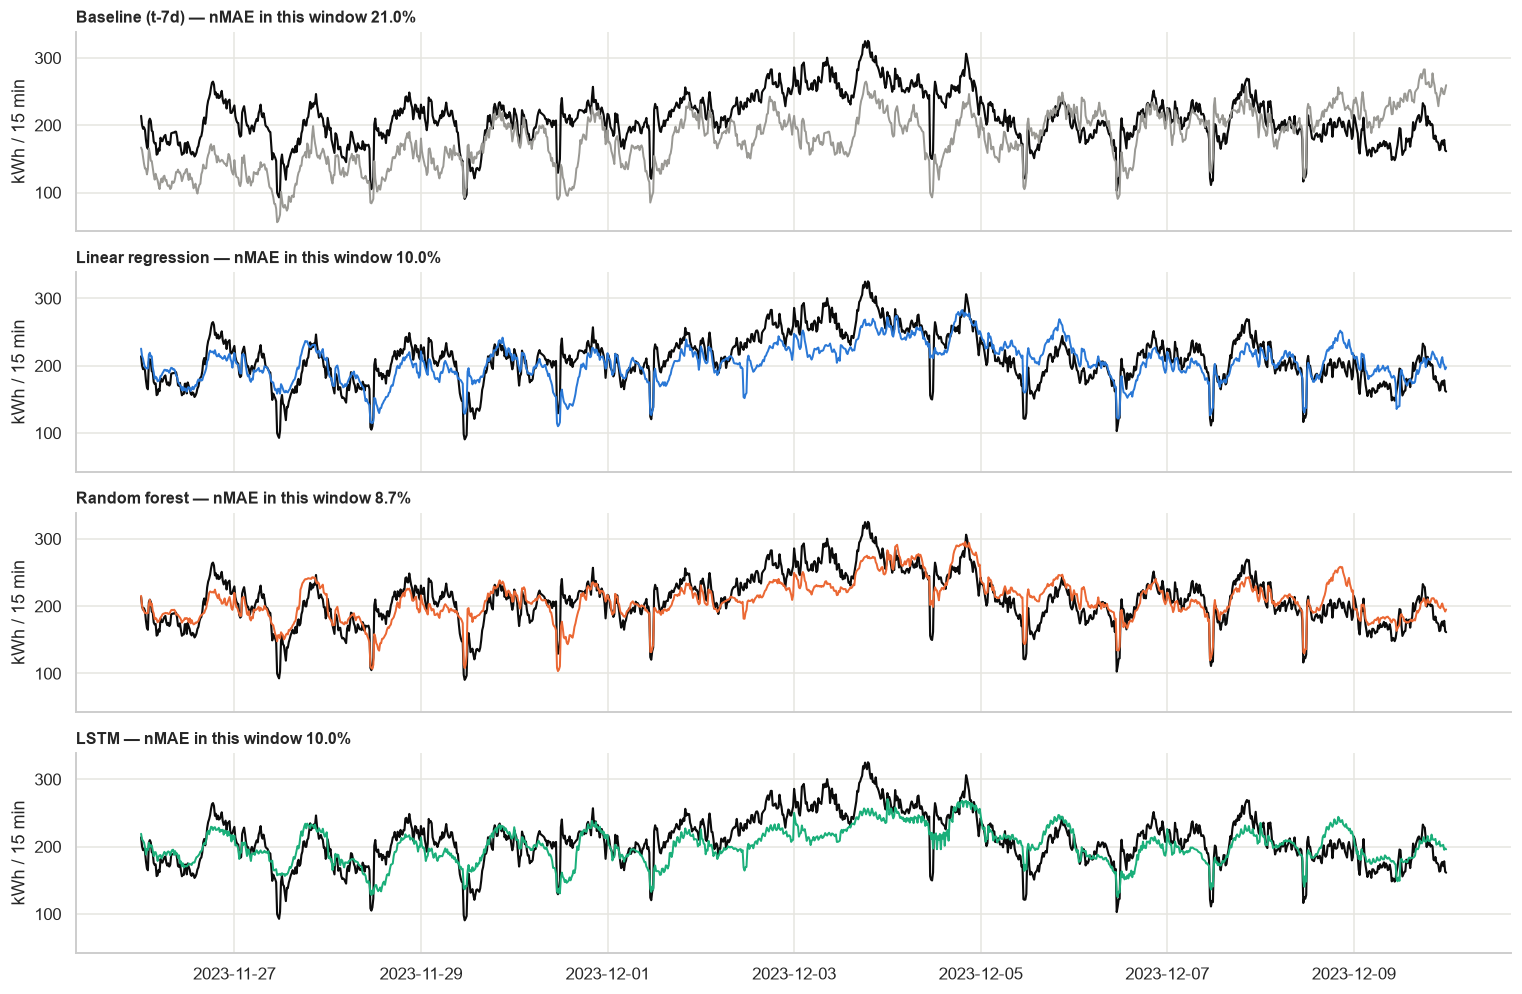

In [71]:
def quarter_hours(days):
    return days.repeat(STEPS) + pd.to_timedelta(np.tile(np.arange(STEPS) * 15, len(days)), unit="min")

# two weeks around the coldest test day; missing days appear as gaps
i0 =max(0, test_days.get_loc(picks["coldest day"]) - 7)
sel = slice(i0, i0 + 14)
ts = quarter_hours(test_days[sel])
full_ts = pd.date_range(ts[0], ts[-1], freq="15min")
on_grid = lambda v: pd.Series(np.asarray(v).ravel(), index=ts).reindex(full_ts)
fig, axes = plt.subplots(len(MODELS), 1, figsize=(14, 2.3 * len(MODELS)), sharex=True, sharey=True)
for ax, m in zip(axes, MODELS):
    ax.plot(full_ts, on_grid(actual_total[sel]), color=C_INK, lw=1.4, label="actual")
    ax.plot(full_ts, on_grid(pred_total[m][sel]), color=MODEL_COLORS[m], lw=1.3, label=m)
    ax.set_title(f"{m} — nMAE in this window "
                 f"{100 * np.abs(pred_total[m][sel] - actual_total[sel]).mean() / actual_total[sel].mean():.1f}%",
                 fontsize=10.5, loc="left")
    ax.set_ylabel("kWh / 15 min")
plt.tight_layout(); plt.show()

### 5.3 Where do the errors occur?

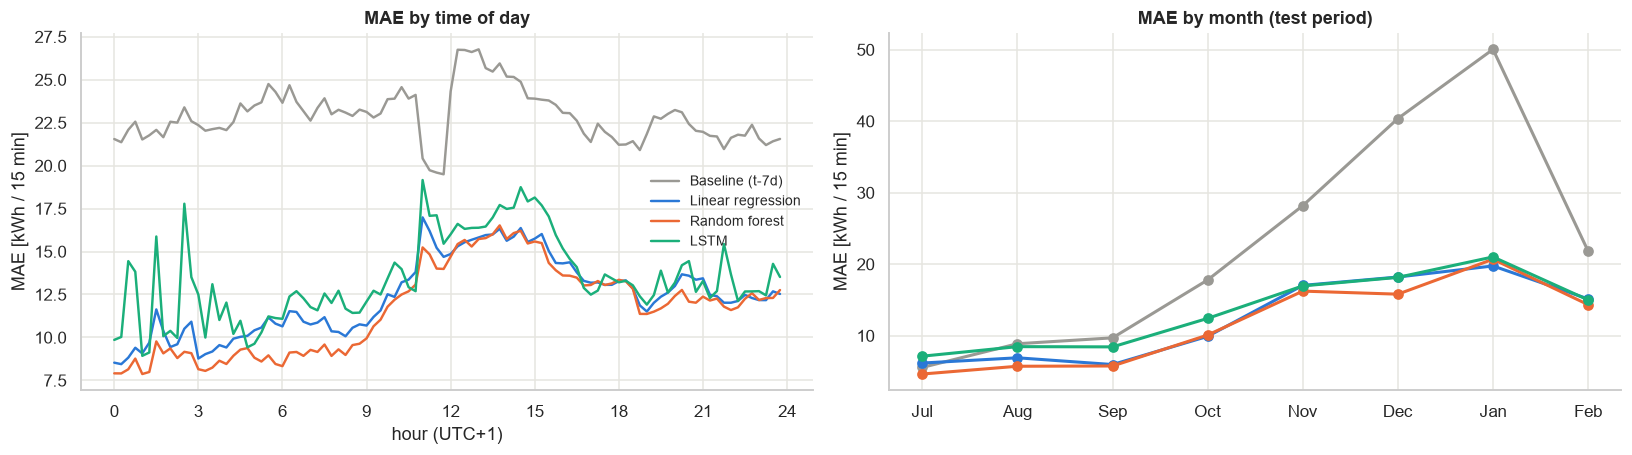

In [72]:
test_month = np.array([d.month for d in test_days])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
for m in MODELS:
    err = np.abs(pred_total[m] - actual_total)
    axes[0].plot(hours, err.mean(0), color=MODEL_COLORS[m], lw=1.6, label=m)
    by_month = pd.Series(err.mean(1)).groupby(test_month).mean()
    order = sorted(by_month.index, key=lambda x: (x < test_days[0].month, x))
    axes[1].plot(range(len(order)), by_month[order].values, marker="o", ms=6, color=MODEL_COLORS[m], label=m)
axes[0].set_title("MAE by time of day"); axes[0].set_xlabel("hour (UTC+1)"); axes[0].set_ylabel("MAE [kWh / 15 min]")
axes[0].set_xticks(range(0, 25, 3)); axes[0].legend(fontsize=9)
axes[1].set_xticks(range(len(order)), [pd.Timestamp(2000, k, 1).strftime("%b") for k in order])
axes[1].set_title("MAE by month (test period)"); axes[1].set_ylabel("MAE [kWh / 15 min]")
plt.tight_layout(); plt.show()

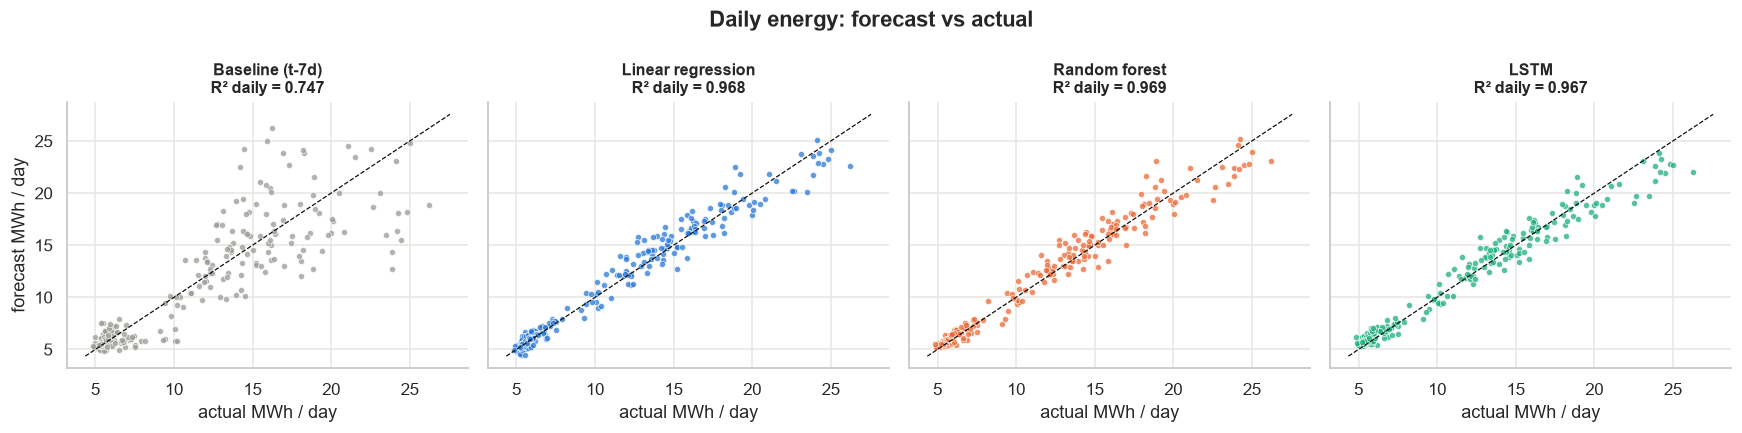

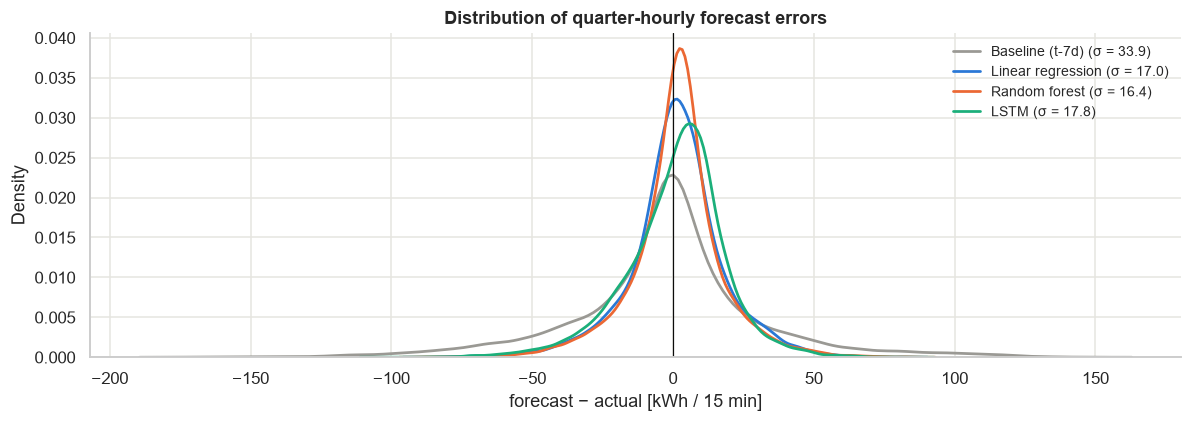

In [73]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharex=True, sharey=True)
de_act = actual_total.sum(1) / 1000
lim = (de_act.min() * .9, de_act.max() * 1.05)
for ax, m in zip(axes, MODELS):
    de_p = pred_total[m].sum(1) / 1000
    ax.scatter(de_act, de_p, s=16, color=MODEL_COLORS[m], alpha=.75, edgecolor="white", linewidth=.5)
    ax.plot(lim, lim, color=C_INK, lw=.8, ls="--")
    ax.set_title(f"{m}\nR² daily = {r2_score(de_act, de_p):.3f}", fontsize=10.5); ax.set_xlabel("actual MWh / day")
axes[0].set_ylabel("forecast MWh / day")
plt.suptitle("Daily energy: forecast vs actual", fontweight="bold"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
for m in MODELS:
    e = (pred_total[m] - actual_total).ravel()
    sns.kdeplot(e, ax=ax, color=MODEL_COLORS[m], lw=1.8, label=f"{m} (σ = {e.std():.1f})")
ax.axvline(0, color=C_INK, lw=.8); ax.set_xlabel("forecast − actual [kWh / 15 min]")
ax.set_title("Distribution of quarter-hourly forecast errors"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

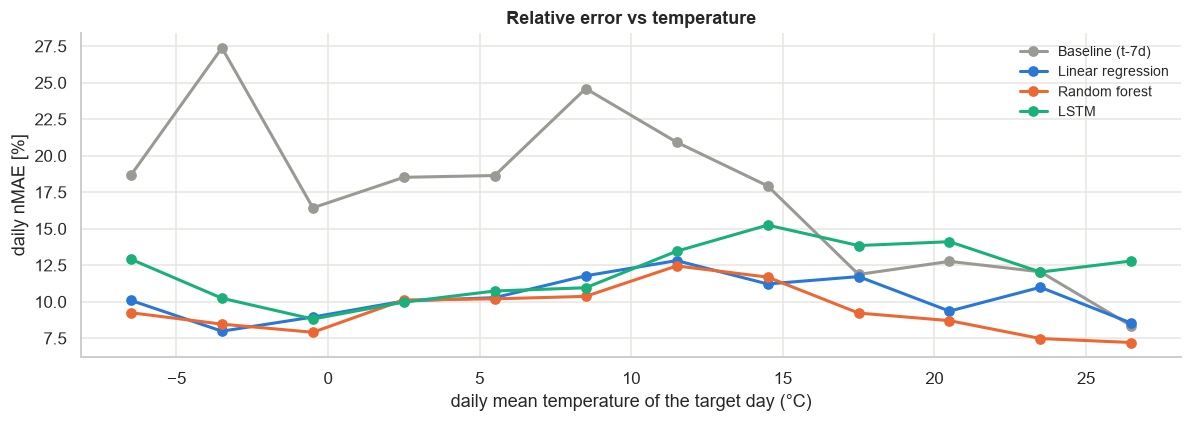

In [74]:
# error vs temperature of the target day
fig, ax = plt.subplots(figsize=(11, 4))
bins = pd.cut(test_temp.values, bins=np.arange(np.floor(test_temp.min()), test_temp.max() + 3, 3))
for m in MODELS:
    daily_nmae = 100 * np.abs(pred_total[m] - actual_total).mean(1) / actual_total.mean(1)
    s = pd.Series(daily_nmae).groupby(bins).mean()
    ax.plot([b.mid for b in s.index], s.values, marker="o", ms=6, color=MODEL_COLORS[m], label=m)
ax.set_xlabel("daily mean temperature of the target day (°C)"); ax.set_ylabel("daily nMAE [%]")
ax.set_title("Relative error vs temperature"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [75]:
# save test forecasts for further analysis (e.g. cost metrics / uncertainty in Levels 2-3)
out = pd.DataFrame({"timestamp": quarter_hours(test_days),
                    "actual_total_kWh": actual_total.ravel(),
                    "n_households_known_at_forecast": n_contract_test.ravel()})
for m in MODELS:
    out[f"forecast_{m}"] = pred_total[m].ravel()
out.to_csv(RESULTS / "test_forecasts_15min.csv", index=False)
print(f"Saved {len(out):,d} rows to {RESULTS / 'test_forecasts_15min.csv'}")
print("Run times [s]:", {k: round(v) for k, v in timings.items()})

Saved 23,040 rows to results\test_forecasts_15min.csv
Run times [s]: {'linear HPO': 5, 'linear fit': 0, 'random forest HPO': 46, 'random forest fit': 15, 'LSTM HPO': 6, 'LSTM fit': 2}


## 6. Conclusions

In [76]:
best_model = res.loc[MODELS, "nMAE [%]"].idxmin()
summary = res.loc[MODELS,
                  ["nMAE [%]", "Daily energy error [%]", "Daily peak error [%]", "Skill vs baseline [%]"]].round(2)
print(f"Best model on the test period: {best_model}")
summary

Best model on the test period: Random forest


,nMAE [%],Daily energy error [%],Daily peak error [%],Skill vs baseline [%]
Baseline (t-7d),19.4600,14.3400,12.2500,0.0000
Linear regression,10.5200,6.5800,7.5600,45.9600
Random forest,9.8900,6.1100,6.7700,49.1700
LSTM,11.4300,7.1700,9.2400,41.2900


CONCLUSIONS_PLACEHOLDER